In [96]:
import numpy as np
import glob
import re
import scipy.stats as stats
import scipy.integrate as integrate
from scipy.optimize import minimize
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from itertools import product
from functools import partial

# for colors on plots
from colormath.color_objects import LabColor, sRGBColor
from colormath.color_conversions import convert_color

Исправить все функции так, чтобы сразу были только нужные вариации (без specifying what condition a parameter is varied across)

# Read data

Data will be a dictionary:
- Subject (1, 2, 3...)
    - Raw individual or aggregated across positions data
        - set size
            - position
                - 16 x 16 matrix with data

In [97]:
POSITIONS = [3, 7, 11, 15] # positions of high-payoff objects
SET_SIZES = [2, 5, 8] # memory set sizes
SUBJECTS = range(1, 9) # subject IDs (1-8), we'll use it later
data_folder = 'Data' # folder containing the subject files

def parse_subject_file(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'\n{2,}', content.strip())

    matrices = []
    for block in blocks:
        lines = [l.strip() for l in block.strip().splitlines() if l.strip()]
        if not lines:
            continue
        rows = []
        for line in lines:
            values = list(map(int, line.split()))
            rows.append(values[1:])
        mat = np.array(rows)
        if mat.shape == (16, 16):
            matrices.append(mat)
    return matrices

data = {}
for filepath in sorted(glob.glob(f'{data_folder}/coloridentification_s*.txt')):
    subject_id = int(re.search(r's(\d+)\.txt', filepath).group(1))
    matrices = parse_subject_file(filepath)

    # Build individual: nested dict ss -> pos
    individual = {}
    for j, ss in enumerate(SET_SIZES):
        individual[ss] = {}  # create inner dict for this set size
        for i, pos in enumerate(POSITIONS):
            idx = j * len(POSITIONS) + i
            individual[ss][pos] = {}
            individual[ss][pos]['data'] = matrices[idx]

    # Build aggregated: last 3 matrices, one per set size
    aggregated = {}
    for j, ss in enumerate(SET_SIZES):
        aggregated[ss] = matrices[12 + j]

    data[subject_id] = {
        'individual': individual,   # keyed by (position, set_size)
        'aggregated': aggregated,   # keyed by set_size
    }

# Save
# with open(f'{data_folder}/coloridentification_all.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [99]:
# Extract observed data and store it in a structured format for model fitting 
# (matrix of shape (C, 16, 16) where C is the number of conditions)
def extract_observed(data, SUBJECTS, SET_SIZES, POSITIONS):
    observed = []
    all_conditions = []

    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:
                mat = data[subj]['individual'][ss][pos]['data']

                observed.append(mat)
                all_conditions.append((subj, ss, pos))

    observed = np.array(observed)  # (C,16,16)

    return observed, all_conditions

## Fit only subject 4

In [100]:
SUBJECTS = [4]

## MDS data

In [101]:
# save data in a structured format for model fitting
data_structured = extract_observed(data, SUBJECTS=SUBJECTS, SET_SIZES=SET_SIZES, POSITIONS=POSITIONS)
data_matrix = data_structured[0]  # (C,16,16)

*data_matrix* format:

--- SUBJECT 1 ---
- set size 2:
    - position 3
    - position 7
    - position 11
    - position 15
- set size 5:
    - position 3
    - position 7
    - position 11
    - position 15
- set size 8:
    - position 3
    - position 7
    - position 11
    - position 15

--- SUBJECT 2 ---

...

--- SUBJECT 8 ---

In [103]:
# Reshaped and summed data matrix
# HP columns are 3, 7, 11, 15 (0-indexed: 2, 6, 10, 14) are zeroed out and then summed across conditions for each subject
n_subj = len(SUBJECTS)
n_ss = len(SET_SIZES)
n_pos = len(POSITIONS)
# --- Reshape to (8, 3, 4, 16, 16) for clean indexing ---
dat_mat = data_matrix.reshape(n_subj, n_ss, n_pos, 16, 16)

# --- Fix high-payoff columns and sum per subject ---
data_matrix_per_subject = np.zeros((n_subj, 16, 16), dtype=float)

for s in range(n_subj):
    for ss in range(n_ss):
        for p_idx, pos in enumerate(POSITIONS):
            hp_col = pos - 1          # 1-indexed position → 0-indexed column
            C      = dat_mat[s, ss, p_idx].copy()
            C[:, hp_col] = C[hp_col, :]   # replace contaminated column with clean row
            data_matrix_per_subject[s] += C

In [104]:
# # data 
# data_matrix_per_subject = data_matrix.reshape(8, 12, 16, 16)#.sum(axis=1)
# data_matrix_per_subject.shape

# Modelling

## Similarity

In [105]:
# # Read saved MDS-solution and weights
# mds_solution = pd.read_csv('MDS_results/stimulus_coordinates.csv')
# mds_weights = pd.read_csv('MDS_results/subject_weights.csv')

# Get coordinates for EACH subject
# coords = mds_solution.loc[:, 'dim1':'dim2']
# for subj in SUBJECTS:
#     for ss in SET_SIZES:
#         for pos in POSITIONS:
#             weights = mds_weights.loc[(mds_weights['subject'] == subj) & 
#                                       (mds_weights['set_size'] == ss) & 
#                                       (mds_weights['position'] == pos), 
#                                       'dim1':'dim2'].values
#             current_coords = coords * weights
#             data[subj]['individual'][ss][pos]['mds_coords'] = current_coords
  

In [106]:
# Use predefined perfectly circular similarity space
n_items = 16
r = 1 # radius of the circle (= distance from center to each point)

angles = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, n_items, endpoint=False)

x = r * np.cos(angles)
y = r * np.sin(angles)

MDS_COORDS = np.column_stack((x, y))

In [107]:
# Save a single MDS solution for all conditions
for subj in SUBJECTS:
    for ss in SET_SIZES:
        for pos in POSITIONS:
            data[subj]['individual'][ss][pos]['mds_coords'] = MDS_COORDS


In [108]:
# Compute distances (Euclidean) for each subject, set size, and position
for subj in SUBJECTS:
    for ss in SET_SIZES:
        for pos in POSITIONS:
            mds_coords = data[subj]['individual'][ss][pos]['mds_coords']
            # mds_coords = mds_coords.to_numpy() # may use it if mds_coords is a DataFrame
            distances = np.linalg.norm(mds_coords[:, None, :] - mds_coords[None, :, :], axis=-1)
            data[subj]['individual'][ss][pos]['mds_distances'] = distances

In [109]:
# Calculate similarity matrices
def calculate_similarity_matrix(distance_matrix, c):
    # Calculate similarity: exp(-c * d_ij)
    return np.exp(-c * distance_matrix)

## SCM

Parameters: 

- c (sensitivity) is set-size specific (3 pars)

- For 16 objects - 15 free parameters, last one is determined $1-\sum_1^{15} b_j$

- B - for high-payoff colors: single parameter for the whole data set

**Total** = 3 + (15+1) + 1 = 19 free parameters (20 total parameters)

In [110]:
def prepare_SCM_data(data, SUBJECTS, SET_SIZES, POSITIONS, 
                 bias_varies_by=(),      # which factors biases differ by
                 c_varies_by=('set_size',)):         # which factors c differs by

    all_conditions = []
    distances = []
    counts = []
    bias_idx = []
    ss_idx = []
    pos_array = []


    def build_lookup(factors):
        keys = []
        if 'subject' in factors: keys.append(SUBJECTS)
        if 'set_size' in factors: keys.append(SET_SIZES)
        if 'position' in factors: keys.append(POSITIONS)
        if not keys:
            return {(): 0}, 1  # single global parameter
        combos = list(product(*[list(k) for k in keys]))
        return {combo: i for i, combo in enumerate(combos)}, len(combos)

    bias_lookup, n_bias_conditions = build_lookup(bias_varies_by)
    c_lookup, n_c_conditions = build_lookup(c_varies_by)

    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:

                all_conditions.append((subj, ss, pos))
                distances.append(data[subj]['individual'][ss][pos]['mds_distances'])
                counts.append(data[subj]['individual'][ss][pos]['data'].sum(axis=1, keepdims=True))

                # Build keys for lookup
                bias_key = tuple(
                    v for f, v in [('subject', subj), ('set_size', ss), ('position', pos)]
                    if f in bias_varies_by
                )
                c_key = tuple(
                    v for f, v in [('subject', subj), ('set_size', ss), ('position', pos)]
                    if f in c_varies_by
                )
                pos_idx = (pos - 1)

                bias_idx.append(bias_lookup[bias_key])
                ss_idx.append(c_lookup[c_key])
                pos_array.append(pos_idx)
    

    return (
        np.array(distances),       # (C,16,16)
        np.array(counts),          # (C,16,1)
        np.array(bias_idx),        # (C,) — bias indices
        np.array(ss_idx),          # (C,) — c indices
        pos_array,
        all_conditions,
        n_bias_conditions,         # how many unique bias conditions
        n_c_conditions             # how many unique c conditions
    )

# Prepare data for model fitting
prepared_SCM_data = prepare_SCM_data(data, SUBJECTS=SUBJECTS, SET_SIZES=SET_SIZES, POSITIONS=POSITIONS)

In [111]:
def unpack_SCM_params(params_vec, n_items=16, n_bias_conditions=1, n_c_conditions=3):
    n_bias_params = (n_items - 1) * n_bias_conditions

    bias_params = params_vec[:n_bias_params]
    B = params_vec[n_bias_params] # boost parameter for high-payoff items
    c_params = params_vec[n_bias_params+1 : n_bias_params+1+n_c_conditions]

    biases = bias_params.reshape(n_bias_conditions, n_items - 1)
    last = 1 - biases.sum(axis=1, keepdims=True)
    biases = np.concatenate([biases, last], axis=1)  # (n_bias_conditions, 16)

    return biases, B, c_params  # (n_bias_conditions,16), (n_c_conditions,)

In [112]:
def SCM(params_vec,
        distances, counts,
        bias_idx, c_idx,
        pos_array,
        n_items=16,
        n_bias_conditions=1, n_c_conditions=3):

    biases, B, c_params = unpack_SCM_params(params_vec, n_items, 
                                            n_bias_conditions, n_c_conditions)

    # --- assign correct bias to each condition ---
    bias_per_condition = biases[bias_idx]                        # (C, 16)

    # --- apply boost if requested ---
    boost_matrix = np.ones_like(bias_per_condition)          # (C, 16)
    boost_matrix[np.arange(len(pos_array)), pos_array] = B  # boost target position
    bias_per_condition = bias_per_condition * boost_matrix
    bias_per_condition = bias_per_condition / bias_per_condition.sum(axis=1, keepdims=True)

    # --- assign correct c to each condition ---
    c_per_condition = c_params[c_idx][:, None, None]             # (C, 1, 1)

    # --- similarity ---
    sim = np.exp(-c_per_condition * distances)                   # (C, 16, 16)

    # --- apply biases ---
    num = sim * bias_per_condition[:, None, :]                   # (C, 16, 16)

    # --- normalize rows ---
    prob = num / num.sum(axis=2, keepdims=True) # (C, 16, 16)

    # --- predicted counts ---
    pred_counts = counts * prob

    return prob, pred_counts

## SCM-mix

Parameters: 

- c (sensitivity) is set-size specific (3 pars)

- For 16 objects - 15 free parameters, last one is determined $1-\sum_1^{15} b_j$

- B - for high-payoff colors: single parameter for the whole data set

- Gamma: single for the whole data set (values make sense between 0.5 and 3):
    - Gamma < 1 flattens the guessing distribution (more uniform), 
    - Gamma > 1 sharpens it (higher bias items get more weight)

- p_mem: probability that an object is remembered. Set-size specific: 3 params

**Total** = 3 + (15+1) + 1 + 3 = 23 free parameters (24 total parameters)

Here also add mixture model: guessing state (1 par or set size specific - 3 params)

In [113]:
def prepare_SCM_mix_data(data, SUBJECTS, SET_SIZES, POSITIONS, 
                         bias_varies_by=(),
                         c_varies_by=('set_size',),
                         memory_varies_by=('set_size',),
                         gamma_varies_by=()):          # empty = single global parameter

    all_conditions = []
    distances = []
    counts = []
    bias_idx = []
    pos_array = []
    c_idx = []
    memory_idx = []
    gamma_idx = []

    def build_lookup(factors):
        keys = []
        if 'subject' in factors: keys.append(list(SUBJECTS))
        if 'set_size' in factors: keys.append(SET_SIZES)
        if 'position' in factors: keys.append(POSITIONS)
        if not keys:
            return {(): 0}, 1
        combos = list(product(*[list(k) for k in keys]))
        return {combo: i for i, combo in enumerate(combos)}, len(combos)

    bias_lookup,   n_bias_conditions   = build_lookup(bias_varies_by)
    c_lookup,      n_c_conditions      = build_lookup(c_varies_by)
    memory_lookup, n_memory_conditions = build_lookup(memory_varies_by)
    gamma_lookup,  n_gamma_conditions  = build_lookup(gamma_varies_by)

    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:

                all_conditions.append((subj, ss, pos))
                distances.append(data[subj]['individual'][ss][pos]['mds_distances'])
                counts.append(data[subj]['individual'][ss][pos]['data'].sum(axis=1, keepdims=True))

                def make_key(varies_by):
                    return tuple(
                        v for f, v in [('subject', subj), ('set_size', ss), ('position', pos)]
                        if f in varies_by
                    )

                bias_idx.append(bias_lookup[make_key(bias_varies_by)])
                pos_array.append(pos - 1)
                c_idx.append(c_lookup[make_key(c_varies_by)])
                memory_idx.append(memory_lookup[make_key(memory_varies_by)])
                gamma_idx.append(gamma_lookup[make_key(gamma_varies_by)])

    return (
        np.array(distances),        # (C,16,16)
        np.array(counts),           # (C,16,1)
        np.array(pos_array),        # (C,)
        np.array(bias_idx),         # (C,)
        np.array(c_idx),            # (C,)
        np.array(memory_idx),       # (C,)
        np.array(gamma_idx),        # (C,)
        all_conditions,
        int(n_bias_conditions),    
        int(n_c_conditions),       
        int(n_memory_conditions), 
        int(n_gamma_conditions)
    )

prepared_SCM_mix_data = prepare_SCM_mix_data(data, SUBJECTS=SUBJECTS, SET_SIZES=SET_SIZES, POSITIONS=POSITIONS)

In [114]:
def unpack_SCM_mix_params(params_vec, 
                          n_items=16, 
                          n_bias_conditions=1, 
                          n_c_conditions=3,
                          n_memory_conditions=3,
                          n_gamma_conditions=1):
    n_bias_params = (n_items - 1) * n_bias_conditions

    bias_params = params_vec[:n_bias_params]
    
    B = params_vec[n_bias_params]
    offset = n_bias_params + 1


    c_params      = params_vec[offset:offset+n_c_conditions]
    memory_params = params_vec[offset+n_c_conditions:offset+n_c_conditions+n_memory_conditions]
    gamma_params  = params_vec[offset+n_c_conditions+n_memory_conditions:offset+n_c_conditions+n_memory_conditions+n_gamma_conditions]

    biases = bias_params.reshape(n_bias_conditions, n_items - 1)
    last = 1 - biases.sum(axis=1, keepdims=True)
    biases = np.concatenate([biases, last], axis=1)  # (n_bias_conditions, 16)

    return biases, B, c_params, memory_params, gamma_params

In [115]:
def SCM_mix(params_vec, 
            distances, counts, pos_array,
            bias_idx,c_idx, memory_idx, gamma_idx,
            n_items=16, 
            n_bias_conditions=1, 
            n_c_conditions=3,
            n_memory_conditions=3,
            n_gamma_conditions=1):

    biases, B, c_params, memory_params, gamma_params = unpack_SCM_mix_params(
        params_vec, n_items,
        n_bias_conditions, n_c_conditions,
        n_memory_conditions, n_gamma_conditions
    )

    # --- assign correct params to each condition ---
    bias_per_condition   = biases[bias_idx]                          # (C,16)
    c_per_condition      = c_params[c_idx][:, None, None]            # (C,1,1)
    memory_per_condition = memory_params[memory_idx][:, None, None]  # (C,1,1)
    gamma_per_condition  = gamma_params[gamma_idx][:, None]          # (C,1)
    
    # --- boost the bias of the high-payoff item ---
    boost_matrix = np.ones_like(bias_per_condition)
    boost_matrix[np.arange(len(pos_array)), pos_array] = B
    bias_per_condition = bias_per_condition * boost_matrix
    bias_per_condition = bias_per_condition / bias_per_condition.sum(axis=1, keepdims=True)

    # --- similarity-based probs (p_ij) ---
    sim = np.exp(-c_per_condition * distances)                       # (C,16,16)
    num = sim * bias_per_condition[:, None, :]                       # (C,16,16)
    p_ij = num / num.sum(axis=2, keepdims=True)                      # (C,16,16)

    # --- g_j: bias raised to gamma, normalized ---
    g_j_raw = bias_per_condition ** gamma_per_condition              # (C,16)
    g_j = g_j_raw / g_j_raw.sum(axis=1, keepdims=True)              # (C,16)
    g_j = g_j[:, None, :]                                           # (C,1,16)

    # --- mixture ---
    prob = memory_per_condition * p_ij + (1 - memory_per_condition) * g_j

    # --- predicted counts ---
    pred_counts = counts * prob

    return prob, pred_counts

## TCC

Parameters:

- d': 16 d's for each object, shared across conditions

- c: 1 similarity function, shared across all conditions

- high-payoff boost: a single value that is added to d' of high-payoff color

- space shrinkage: 
    - intercept: 2, for ss-5 and ss-8
    - slope: 2, for ss-5 and ss-8
    - they indicate how the memory (d') space is shrunk in set-size-5 and -8 conditions, compared to set size 2

**Total:** 16 + 1 + 1 + (2+2) = 22 free parameters

In [116]:
# prepare data for TCC model
def prepare_TCC_data(data, SUBJECTS, SET_SIZES, POSITIONS):
    all_conditions = []
    distances = []
    counts = []
    pos_array = []
    ss_idx = []  # 0-indexed set size index

    for subj in SUBJECTS:
        for i_ss, ss in enumerate(SET_SIZES):
            for pos in POSITIONS:
                all_conditions.append((subj, ss, pos))
                distances.append(data[subj]['individual'][ss][pos]['mds_distances'])
                counts.append(data[subj]['individual'][ss][pos]['data'].sum(axis=1, keepdims=True))
                pos_array.append(pos - 1)
                ss_idx.append(i_ss)

    return (
        np.array(distances),  # (C,16,16)
        np.array(counts),     # (C,16,1)
        np.array(pos_array),  # (C,)
        np.array(ss_idx),     # (C,) 0-indexed set size
        all_conditions
    )

prepared_TCC_data = prepare_TCC_data(data, SUBJECTS, SET_SIZES, POSITIONS)

In [117]:
# Compute probabilities
def compute_pred_probs_TCC(familiarity, n_points=100, x_range=(-10, 10)):
    # handle both 2D and 3D input
    squeeze = familiarity.ndim == 2
    if squeeze:
        familiarity = familiarity[None, :, :]  # (1, 16, 16)

    x_grid = np.linspace(x_range[0], x_range[1], n_points)
    dx     = x_grid[1] - x_grid[0]

    fam_exp = familiarity[:, :, :, None]         # (C, 16, 16, 1)
    x_exp   = x_grid[None, None, None, :]        # (1,  1,  1,  n_points)

    cdfs            = stats.norm.cdf(x_exp, loc=fam_exp)   # (C, 16, 16, n_points)
    log_cdfs        = np.log(np.clip(cdfs, 1e-300, 1))
    log_prod_all    = log_cdfs.sum(axis=2, keepdims=True)   # (C, 16, 1,  n_points)
    log_prod_excl_j = log_prod_all - log_cdfs               # (C, 16, 16, n_points)
    prod_excl_j     = np.exp(log_prod_excl_j)
    pdf_j           = stats.norm.pdf(x_exp, loc=fam_exp)

    pred_probs = np.sum(pdf_j * prod_excl_j * dx, axis=3)  # (C, 16, 16)

    return pred_probs[0] if squeeze else pred_probs

In [118]:
# TCC
def TCC(params_vec, distances, counts, pos_array, ss_idx,
        n_items=16, n_points=100, x_range=(-10, 10)):

    d_params          = params_vec[:n_items]
    c                 = params_vec[n_items]
    high_payoff_boost = params_vec[n_items + 1]
    slopes            = np.concatenate([[1.0], params_vec[n_items+2:n_items+4]])

    n_cond      = 12
    dist_unique = distances[:n_cond]
    pos_unique  = pos_array[:n_cond]
    ss_unique   = ss_idx[:n_cond]

    slopes_per_cond = slopes[ss_unique]
    d_adjusted = np.clip(slopes_per_cond[:, None] * d_params[None, :], 0, None)

    sim         = calculate_similarity_matrix(dist_unique, c)
    familiarity = sim * d_adjusted[:, :, None]
    familiarity[np.arange(n_cond), :, pos_unique] += high_payoff_boost

    pred_probs_unique = compute_pred_probs_TCC(familiarity, n_points, x_range)  # (12, 16, 16)

    n_subj      = len(distances) // n_cond
    pred_probs  = np.tile(pred_probs_unique, (n_subj, 1, 1))
    pred_counts = counts * pred_probs

    return pred_probs, pred_counts

## TCC-mix

In [119]:
def unpack_TCC_mix_params(params_vec, n_items=16, n_ss=3, bias_fixed=False):
    d_params          = params_vec[:n_items]                                     # 0-15
    c                 = params_vec[n_items]                                      # 16
    high_payoff_boost = params_vec[n_items+1]                                    # 17
    slopes            = np.concatenate([[1.0], params_vec[n_items+2:n_items+4]]) # 18-19

    if bias_fixed:
        B     = params_vec[n_items+4]                                            # 20
        p_mem = params_vec[n_items+5:n_items+5+n_ss]                            # 21-23
        biases = np.repeat(1/n_items, n_items)
    else:
        bias_params = params_vec[n_items+4:n_items+19]                          # 20-34
        last_bias   = 1 - bias_params.sum()
        biases      = np.append(bias_params, last_bias)
        B           = params_vec[n_items+19]                                     # 35
        p_mem       = params_vec[n_items+20:n_items+20+n_ss]                    # 36-38

    return d_params, c, high_payoff_boost, slopes, biases, B, p_mem

In [120]:
def TCC_mix(params_vec, distances, counts, pos_array, ss_idx,
            n_items=16, n_ss=3, n_points=100, x_range=(-10, 10),
            bias_fixed=False):

    d_params, c, high_payoff_boost, slopes, biases, B, p_mem = \
        unpack_TCC_mix_params(params_vec, n_items, n_ss, bias_fixed)

    n_cond      = 12
    dist_unique = distances[:n_cond]
    pos_unique  = pos_array[:n_cond]
    ss_unique   = ss_idx[:n_cond]

    slopes_per_cond = slopes[ss_unique]
    d_adjusted = np.clip(slopes_per_cond[:, None] * d_params[None, :], 0, None)

    sim         = calculate_similarity_matrix(dist_unique, c)
    familiarity = sim * d_adjusted[:, :, None]
    familiarity[np.arange(n_cond), :, pos_unique] += high_payoff_boost

    p_tcc = compute_pred_probs_TCC(familiarity, n_points, x_range)

    biases_boosted = np.tile(biases, (n_cond, 1))
    boost_matrix   = np.ones_like(biases_boosted)
    boost_matrix[np.arange(n_cond), pos_unique] = B
    biases_boosted = biases_boosted * boost_matrix
    biases_boosted = biases_boosted / biases_boosted.sum(axis=1, keepdims=True)
    biases_exp     = biases_boosted[:, None, :]

    p_mem_per_cond    = p_mem[ss_unique][:, None, None]
    pred_probs_unique = p_mem_per_cond * p_tcc + (1 - p_mem_per_cond) * biases_exp

    n_subj      = len(distances) // n_cond
    pred_probs  = np.tile(pred_probs_unique, (n_subj, 1, 1))
    pred_counts = counts * pred_probs

    return pred_probs, pred_counts

# Optimization

## Set-up

In [121]:
total_counts = data_matrix.sum()
def validity_checks(params, model, prep_data=None):
    if model is SCM:
        biases, _, _ = unpack_SCM_params(params,
                                         n_items=16,
                                         n_bias_conditions=prep_data[-2],
                                         n_c_conditions=prep_data[-1])
        if np.any(biases[-1] <= 0):
            return False
    elif model is SCM_mix:
        biases, _, _, memory_params, gamma_params = unpack_SCM_mix_params(
            params,
            n_bias_conditions=prep_data[-4],
            n_c_conditions=prep_data[-3],
            n_memory_conditions=prep_data[-2],
            n_gamma_conditions=prep_data[-1]
        )
        if np.any(biases[-1] <= 0) or np.any(memory_params < 0) or np.any(memory_params > 1) or np.any(gamma_params < 0):
            return False
    elif model is TCC:
        return True
    elif getattr(model, 'func', None) is TCC_mix and model.keywords.get('bias_fixed', False) == False:
        _, _, _, _, biases, _, p_mem = unpack_TCC_mix_params(params, bias_fixed=False)
        if biases[-1] <= 0 or np.any(p_mem < 0) or np.any(p_mem > 1):
            return False
    elif getattr(model, 'func', None) is TCC_mix and model.keywords.get('bias_fixed', False) == True:
        _, _, _, _, _, _, p_mem = unpack_TCC_mix_params(params, bias_fixed=True)
        if np.any(p_mem < 0) or np.any(p_mem > 1):
            return False
    else:
        return False
    return True

In [122]:
# NLL
def neg_log_likelihood(params, model, observed_counts, prep_data):
    if not validity_checks(params, model, prep_data):
        return 1e10

    if model is SCM:
        predicted_probs = model(params,
                                *prep_data[:5],
                                n_items=16,
                                n_bias_conditions=prep_data[-2],
                                n_c_conditions=prep_data[-1])[0]
    elif model is SCM_mix:
        predicted_probs = model(params,
                                *prep_data[:7],
                                n_bias_conditions=prep_data[-4],
                                n_c_conditions=prep_data[-3],
                                n_memory_conditions=prep_data[-2],
                                n_gamma_conditions=prep_data[-1])[0]
    elif model is TCC:
        predicted_probs = model(params,
                                *prep_data[:4],
                                n_items=16,
                                n_points=100, x_range=(-10, 10))[0]
    elif getattr(model, 'func', None) is TCC_mix:
        # works for both TCC_mix_free and TCC_mix_fixed
        predicted_probs = model(params,
                                *prep_data[:4],
                                n_items=16, n_ss=3,
                                n_points=100, x_range=(-10, 10))[0]

    eps = 1e-12
    return -np.sum(observed_counts * np.log(predicted_probs + eps)) / total_counts

In [123]:
def fit_model(neg_log_likelihood, initial_params, model, 
              observed_counts, prep_data, bounds,
              warmup_options=None, final_options=None, print_every=10):
    
    if warmup_options is None:
        warmup_options = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 1000, 'maxfun': 10000}
    if final_options is None:
        final_options = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 10000, 'maxfun': 100000}

    def make_callback(stage):
        iterations = [0]
        def callback(x):
            iterations[0] += 1
            if iterations[0] % print_every == 0:
                loss = neg_log_likelihood(x, model, observed_counts, prep_data)
                print(f"  [{stage}] Iteration {iterations[0]:4d}: loss = {loss:.6f}")
        return callback

    # --- warm up ---
    print("=== Warmup ===")
    fit_warmup = minimize(
        neg_log_likelihood, initial_params,
        args=(model, observed_counts, prep_data),
        bounds=bounds, method='L-BFGS-B',
        callback=make_callback('warmup'),
        options=warmup_options
    )
    print(f"Warmup done: {fit_warmup.message} | Loss: {fit_warmup.fun:.6f}\n")

    # --- final fit ---
    print("=== Final fit ===")
    fit_final = minimize(
        neg_log_likelihood, fit_warmup.x,
        args=(model, observed_counts, prep_data),
        bounds=bounds, method='L-BFGS-B',
        callback=make_callback('final'),
        options=final_options
    )
    print(f"Final done:  {fit_final.message} | Loss: {fit_final.fun:.6f}")

    return fit_final

## Running 

In mixture models use optimal parameters from their counterparts for warm-up

### SCM

In [124]:
# SCM
initial_params_SCM = np.concatenate([
    np.repeat(1/16, 15),   # biases
    np.array([1]),              # boost parameter B
    np.repeat(0.01, 3)        # c
])
bounds_SCM = [(0, 1)] * 15 + [(0, None)] + [(0, None)] * 3 # biases between 0 and 1, boost, c >= 0
SCM_fit = fit_model(neg_log_likelihood=neg_log_likelihood,
                    initial_params=initial_params_SCM,
                    model=SCM,
                    observed_counts=data_matrix,
                    prep_data=prepared_SCM_data,
                    bounds=bounds_SCM)

=== Warmup ===
  [warmup] Iteration   10: loss = 2.248932
  [warmup] Iteration   20: loss = 1.480480
  [warmup] Iteration   30: loss = 1.466365
  [warmup] Iteration   40: loss = 1.387606
  [warmup] Iteration   50: loss = 1.382109
  [warmup] Iteration   60: loss = 1.367394
  [warmup] Iteration   70: loss = 1.366491
  [warmup] Iteration   80: loss = 1.363706
  [warmup] Iteration   90: loss = 1.360323
  [warmup] Iteration  100: loss = 1.342958
  [warmup] Iteration  110: loss = 1.335714
  [warmup] Iteration  120: loss = 1.333787
  [warmup] Iteration  130: loss = 1.333682
Warmup done: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.333662

=== Final fit ===
Final done:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.333662


In [125]:
# Parameters: 15 biases, 1 boost, 3 c params
print("SCM best-fitting parameters:\n\n")
print("Biases (for 15 items, 16th is 1 - sum):")
print(SCM_fit.x[:15], end="\n\n")
print(f"Boost parameter B (for high-payoff items): {SCM_fit.x[15]:.4f}", end="\n\n")
print("c parameters for each set size:")
print(SCM_fit.x[16:19])

SCM best-fitting parameters:


Biases (for 15 items, 16th is 1 - sum):
[0.03510851 0.02631832 0.06337751 0.05055275 0.0276338  0.0902746
 0.08240309 0.04535066 0.02258393 0.05682684 0.10240386 0.09768218
 0.0944935  0.06711495 0.07919513]

Boost parameter B (for high-payoff items): 14.1551

c parameters for each set size:
[6.7465688  2.36126221 1.4697546 ]


### SCM-mix

In [ ]:
initial_params_SCM_mix = np.concatenate([
    SCM_fit.x[:15],          # biases from SCM solution
    [1.0],                # boost parameter B: start neutral
    SCM_fit.x[-3:],               # c from SCM solution
    [0.9, 0.8, 0.7],    # memory: start high (mostly memory-based)
    [1.0]                # gamma: neutral
])

bounds_SCM_mix = (
    [(0, 1)]   * 15 +   # biases
    [(0, None)] * 1  +   # boost parameter B
    [(0, None)] * 3  +   # c
    [(0, 1)]   * 3  +   # p_mem (probability, must be 0-1)
    [(0, None)] * 1      # gamma
)

SCM_mix_fit = fit_model(neg_log_likelihood = neg_log_likelihood,
                        initial_params=initial_params_SCM_mix,
                        model=SCM_mix,
                        observed_counts=data_matrix,
                        prep_data=prepared_SCM_mix_data,
                        bounds=bounds_SCM_mix)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.524269
  [warmup] Iteration   20: loss = 1.302318
  [warmup] Iteration   30: loss = 1.234102
  [warmup] Iteration   40: loss = 1.230684
  [warmup] Iteration   50: loss = 1.226823
  [warmup] Iteration   60: loss = 1.208359
  [warmup] Iteration   70: loss = 1.208173
  [warmup] Iteration   80: loss = 1.208086
  [warmup] Iteration   90: loss = 1.207749
  [warmup] Iteration  100: loss = 1.207335
  [warmup] Iteration  110: loss = 1.207218
  [warmup] Iteration  120: loss = 1.207137
  [warmup] Iteration  130: loss = 1.207114
  [warmup] Iteration  140: loss = 1.206962
  [warmup] Iteration  150: loss = 1.206846
  [warmup] Iteration  160: loss = 1.206828
  [warmup] Iteration  170: loss = 1.206771
  [warmup] Iteration  180: loss = 1.206748
  [warmup] Iteration  190: loss = 1.206741
Warmup done: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.206733

=== Final fit ===
Final done:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 

In [130]:
# Parameters: 15 biases, 1 boost, 3 c, 3 memory, 1 gamma params
print("\n\nSCM-mixed best-fitting parameters:\n\n")
print("Biases (for 15 items, 16th is 1 - sum):")
print(SCM_mix_fit.x[:15], end="\n\n")
print(f"Boost parameter B (for high-payoff items): {SCM_mix_fit.x[15]:.4f}", end="\n\n")
print("c parameters for each set size:")
print(SCM_mix_fit.x[16:19], end="\n\n")
print("Memory parameters (p_mem) for each set size:")
print(SCM_mix_fit.x[19:22], end="\n\n")
print(f"Gamma parameter (exponent for bias in guessing): {SCM_mix_fit.x[22]:.4f}")



SCM-mixed best-fitting parameters:


Biases (for 15 items, 16th is 1 - sum):
[0.03048444 0.02440501 0.07663532 0.05512311 0.0308828  0.09700438
 0.09831285 0.04428097 0.01774414 0.04728393 0.10086889 0.09002234
 0.08410098 0.06086562 0.08720367]

Boost parameter B (for high-payoff items): 3.9075

c parameters for each set size:
[6.84328447 4.34445754 3.86915947]

Memory parameters (p_mem) for each set size:
[0.98560907 0.68772382 0.45085381]

Gamma parameter (exponent for bias in guessing): 2.4732


### TCC

In [131]:
initial_params_TCC = np.concatenate([
    stats.norm.rvs(4, 0.2, size=16, random_state=1),  # d parameters for each item
    [0.01],            # c parameter
    [0.5],              # familiarity boost for high-payoff item
    [0.6, 0.3],     # slopes for set sizes 5 and 8 (2 is baseline with slope=1)
])
bounds_TCC = (
    [(0, None)] * 16 +   # d parameters >= 0
    [(0, None)] * 1  +   # c >= 0
    [(0, None)] * 1  +   # boost >= 0
    [(0, None)] * 2    # slopes >= 0
)

TCC_fit = fit_model(neg_log_likelihood = neg_log_likelihood,
                        initial_params=initial_params_TCC,
                        model=TCC,
                        observed_counts=data_matrix,
                        prep_data=prepared_TCC_data,
                        bounds=bounds_TCC)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.291373
  [warmup] Iteration   20: loss = 1.276377
  [warmup] Iteration   30: loss = 1.271152
Warmup done: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.270680

=== Final fit ===
Final done:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.270680


In [132]:
# Parameters: 16 d's, 1 c, 1 boost, 2 slopes
print("\n\nTCC best-fitting parameters:\n\n")
print("d parameters for each item:")
print(TCC_fit.x[:16], end="\n\n")
print(f"c parameter (similarity sensitivity): {TCC_fit.x[16]:.4f}", end="\n\n")
print(f"Familiarity boost for high-payoff item: {TCC_fit.x[17]:.4f}", end="\n\n")
print("Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):")
print(TCC_fit.x[18:20], end="\n\n")



TCC best-fitting parameters:


d parameters for each item:
[5.02437913 4.53522276 4.33054629 4.64082155 4.40138605 5.35139804
 4.54856113 4.60377189 4.48370932 5.70791549 5.88430358 6.12445449
 7.25963127 5.90195422 4.80954492 5.24451892]

c parameter (similarity sensitivity): 1.3628

Familiarity boost for high-payoff item: 1.8754

Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):
[0.52449325 0.36184649]



### TCC-mix

In [134]:
# Need it for optimization
TCC_mix_free   = partial(TCC_mix, bias_fixed=False)  # free biases
TCC_mix_fixed  = partial(TCC_mix, bias_fixed=True)   # fixed biases = 1/16

#### Free biases

In [135]:
initial_params_TCC_mix_free = np.concatenate([
    TCC_fit.x[:16],       # d'
    [TCC_fit.x[16]],      # c
    [TCC_fit.x[17]],      # high_payoff_boost
    TCC_fit.x[18:20],     # slopes
    np.repeat(1/16, 15),  # biases
    [1.5],                # B
    [0.8, 0.7, 0.6]       # p_mem
])
bounds_TCC_mix_free = (
    [(0, None)] * 16 +    # d'
    [(0, None)]      +    # c
    [(0, None)]      +    # boost
    [(0, None)] * 2  +    # slopes
    [(0, None)] * 15 +    # biases
    [(0, None)]      +    # B
    [(0, 1)]    * 3       # p_mem
)

TCC_mix_free_fit = fit_model(
    neg_log_likelihood,
    initial_params_TCC_mix_free,
    TCC_mix_free,
    data_matrix,
    prepared_TCC_data,
    bounds_TCC_mix_free
)

=== Warmup ===
Warmup done: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | Loss: 1.266889

=== Final fit ===
  [final] Iteration   10: loss = 1.255823
  [final] Iteration   20: loss = 1.255560
  [final] Iteration   30: loss = 1.254805
Final done:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.254664


In [149]:
# Parameters: 16 d's, 1 c, 1 HP familiarity boost, 2 slopes, 15 biases, 1 HP boost for guessing, 3 p_mem
d, c, hp_boost, slopes, biases, B, p_mem = unpack_TCC_mix_params(TCC_mix_free_fit.x)
print("\n\nTCC-mixture (free bias) best-fitting parameters:\n\n")
print("d parameters for each item:")
print(d, end="\n\n")
print(f"c parameter (similarity sensitivity): {c:.4f}", end="\n\n")
print(f"Familiarity boost for high-payoff item: {hp_boost:.4f}", end="\n\n")
print("Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):")
print(slopes, end="\n\n")
print("Biases for each item:")
print(biases, end='\n\n')
print(f'Boost for high-payoff guess: {B}', end='\n\n')
print(f'p_mem: {p_mem}')



TCC-mixture (free bias) best-fitting parameters:


d parameters for each item:
[5.20315358 4.78156207 4.86900639 4.98830965 4.52656349 5.39716386
 4.54684578 4.69287819 4.54042796 5.59834317 5.71858112 5.97235003
 7.21576625 6.0270632  5.02228534 5.35820782]

c parameter (similarity sensitivity): 1.3299

Familiarity boost for high-payoff item: 2.0288

Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):
[1.         0.5730362  0.41527988]

Biases for each item:
[0.         0.         0.01451121 0.         0.         0.1349525
 0.2330958  0.00605768 0.         0.0188323  0.29217363 0.0992189
 0.04683167 0.         0.14037056 0.01395576]

Boost for high-payoff guess: 1.9124300816610516

p_mem: [1.         0.93352502 0.87993067]


#### Fixed biases

In [144]:
initial_params_TCC_mix_fixed = np.concatenate([
    TCC_fit.x[:16],       # d'
    [TCC_fit.x[16]],      # c
    [TCC_fit.x[17]],      # high_payoff_boost
    TCC_fit.x[18:20],     # slopes
    [1.5],                # B
    [0.97, 0.70, 0.46]       # p_mem
])
bounds_TCC_mix_fixed = (
    [(0, None)] * 16 +    # d'
    [(0, None)]      +    # c
    [(0, None)]      +    # boost
    [(0, None)] * 2  +    # slopes
    [(0, None)]      +    # B
    [(0, 1)]    * 3       # p_mem
)

TCC_mix_fixed_fit = fit_model(
    neg_log_likelihood,
    initial_params_TCC_mix_fixed,
    TCC_mix_fixed,
    data_matrix,
    prepared_TCC_data,
    bounds_TCC_mix_fixed
)

=== Warmup ===
Warmup done: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.270012

=== Final fit ===
Final done:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | Loss: 1.270012


In [ ]:
# Parameters: 16 d's, 1 c, 1 HP familiarity boost, 2 slopes, 1 HP boost for guessing, 3 p_mem
d, c, hp_boost, slopes, biases, B, p_mem = unpack_TCC_mix_params(TCC_mix_fixed_fit.x, bias_fixed=True)
print("\n\nTCC-mixture (fixed bias) best-fitting parameters:\n\n")
print("d parameters for each item:")
print(d, end="\n\n")
print(f"c parameter (similarity sensitivity): {c:.4f}", end="\n\n")
print(f"Familiarity boost for high-payoff item: {hp_boost:.4f}", end="\n\n")
print("Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):")
print(slopes, end="\n\n")
print("Biases (fixed at 1/16)")
print(biases, end="\n\n")
print(f'Boost for high-payoff guess: {B}', end='\n\n')
print(f'p_mem: {p_mem}')



TCC-mixture best-fitting parameters:


d parameters for each item:
[5.02472005 4.53548734 4.33733539 4.64319287 4.40275541 5.3531997
 4.55183932 4.60430901 4.48219669 5.70648626 5.88563647 6.12383927
 7.25739293 5.90550313 4.81588547 5.24639806]

c parameter (similarity sensitivity): 1.3578

Familiarity boost for high-payoff item: 1.9064

Slopes for set sizes 5 and 8 (relative to baseline of 1.0 for set size 2):
[1.         0.54338782 0.36460761]

Biases (fixed at 1/16)
[0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625
 0.0625 0.0625 0.0625 0.0625 0.0625 0.0625]

Boost for high-payoff guess: 1.5378167443630377

p_mem: [1.         0.97953116 1.        ]


# Model Comparison

## Predictions

In [150]:
def get_predictions(fit_params, model, prepared_data, data_matrix,
                    SUBJECTS, SET_SIZES, POSITIONS,
                    n_data_args=5, model_kwargs=None):
    if model_kwargs is None:
        model_kwargs = {}

    n_subj = len(list(SUBJECTS))
    n_ss   = len(SET_SIZES)
    n_pos  = len(POSITIONS)
    n_cond = n_ss * n_pos

    pred_probs_all = model(fit_params, *prepared_data[:n_data_args], **model_kwargs)[0]

    obs_counts = data_matrix.reshape(n_subj, n_cond, 16, 16)
    obs_props  = obs_counts / (obs_counts.sum(axis=-1, keepdims=True) + 1e-12)

    pred_probs = pred_probs_all[:n_cond]  # (12, 16, 16)

    return {
        'pred_probs': pred_probs,          # (12, 16, 16)
        'obs_props':  obs_props,           # (n_subj, 12, 16, 16)
        'n_subj':     n_subj,
        'n_ss':       n_ss,
        'n_pos':      n_pos,
        'n_cond':     n_cond
    }

In [151]:
# SCM
SCM_predictions = get_predictions(
    SCM_fit.x, SCM, prepared_SCM_data, data_matrix,
    SUBJECTS, SET_SIZES, POSITIONS,
    n_data_args=5,
    model_kwargs={'n_bias_conditions': 1, 'n_c_conditions': 3}
)

# SCM-mix
SCM_mix_predictions = get_predictions(
    SCM_mix_fit.x, SCM_mix, prepared_SCM_mix_data, data_matrix,
    SUBJECTS, SET_SIZES, POSITIONS,
    n_data_args=7,
    model_kwargs={'n_bias_conditions': 1, 'n_c_conditions': 3,
                  'n_memory_conditions': 3, 'n_gamma_conditions': 1}
)

# TCC
TCC_predictions = get_predictions(
    TCC_fit.x, TCC, prepared_TCC_data, data_matrix,
    SUBJECTS, SET_SIZES, POSITIONS,
    n_data_args=4,
    model_kwargs={'n_points': 100, 'x_range': (-10, 10)}
)

# TCC-mix (free biases)
TCC_mix_free_predictions = get_predictions(
    TCC_mix_free_fit.x, TCC_mix_free, prepared_TCC_data, data_matrix,
    SUBJECTS, SET_SIZES, POSITIONS,
    n_data_args=4,
    model_kwargs={'n_items': 16, 'n_ss': 3, 'n_points': 100, 'x_range': (-10, 10)}
)

# TCC-mix (fixed biases)
TCC_mix_fixed_predictions = get_predictions(
    TCC_mix_fixed_fit.x, TCC_mix_fixed, prepared_TCC_data, data_matrix,
    SUBJECTS, SET_SIZES, POSITIONS,
    n_data_args=4,
    model_kwargs={'n_items': 16, 'n_ss': 3, 'n_points': 100, 'x_range': (-10, 10)}
)

In [ ]:
# Save data if needed

need_to_save_all = False
need_to_save_4 = False

if need_to_save_all:
    with open('predictions/all_subjects_preds.pkl', 'wb') as f:
        pickle.dump({
            'SCM_predictions': SCM_predictions,
            'SCM_mix_predictions': SCM_mix_predictions,
            'TCC_predictions': TCC_predictions,
            'TCC_mix_free_predictions': TCC_mix_free_predictions,
            'TCC_mix_fixed_predictions': TCC_mix_fixed_predictions
        }, f)
elif need_to_save_4:
    with open('predictions/subject_4_preds.pkl', 'wb') as f:
        pickle.dump({
            'SCM_predictions': SCM_predictions,
            'SCM_mix_predictions': SCM_mix_predictions,
            'TCC_predictions': TCC_predictions,
            'TCC_mix_free_predictions': TCC_mix_free_predictions,
            'TCC_mix_fixed_predictions': TCC_mix_fixed_predictions
        }, f)

# Load them back later:
# with open('predictions/all_subjects_preds.pkl', 'rb') as f:
#     predictions_all = pickle.load(f)
# with open('predictions/subject_4_preds.pkl', 'rb') as f:
#     predictions_4 = pickle.load(f)

## Metrics

In [177]:
def compute_aic_bic(fit, total_counts):
    k   = len(fit.x)
    nll = fit.fun * total_counts
    aic = 2 * k + 2 * nll
    bic = k * np.log(total_counts) + 2 * nll
    return aic, bic

models = {
    'SCM':         SCM_fit,
    'SCM-mix':     SCM_mix_fit,
    'TCC':         TCC_fit,
    'TCC-mix (free bias)': TCC_mix_free_fit,
    'TCC-mix (fixed bias)':TCC_mix_fixed_fit,
}
total_counts = data_matrix.sum()

In [178]:
aic_values = {}
bic_values = {}

for name, fit in models.items():
    aic, bic = compute_aic_bic(fit, total_counts)
    aic_values[name] = aic
    bic_values[name] = bic

best_aic = min(aic_values, key=aic_values.get)
best_bic = min(bic_values, key=bic_values.get)

print(f"{'Model':<22} {'n_params':<13} {'NLL':<13} {'AIC':<8} {'AIC_best':<14} {'BIC':<8} {'BIC_best'}")
print("-" * 95)
for name, fit in models.items():
    nll  = fit.fun * total_counts
    aic  = aic_values[name]
    bic  = bic_values[name]
    aic_flag = '***' if name == best_aic else ''
    bic_flag = '***' if name == best_bic else ''
    print(f"{name:<24} {len(fit.x):<10} {nll:<12.2f} {aic:<12.2f} {aic_flag:<10} {bic:<12.2f} {bic_flag:<10}")

Model                  n_params      NLL           AIC      AIC_best       BIC      BIC_best
-----------------------------------------------------------------------------------------------
SCM                      19         5121.26      10280.52                10399.33               
SCM-mix                  23         4633.86      9313.71      ***        9457.54      ***       
TCC                      20         4879.41      9798.83                 9923.89                
TCC-mix (free bias)      39         4817.91      9713.82                 9957.69                
TCC-mix (fixed bias)     24         4876.85      9801.69                 9951.77                


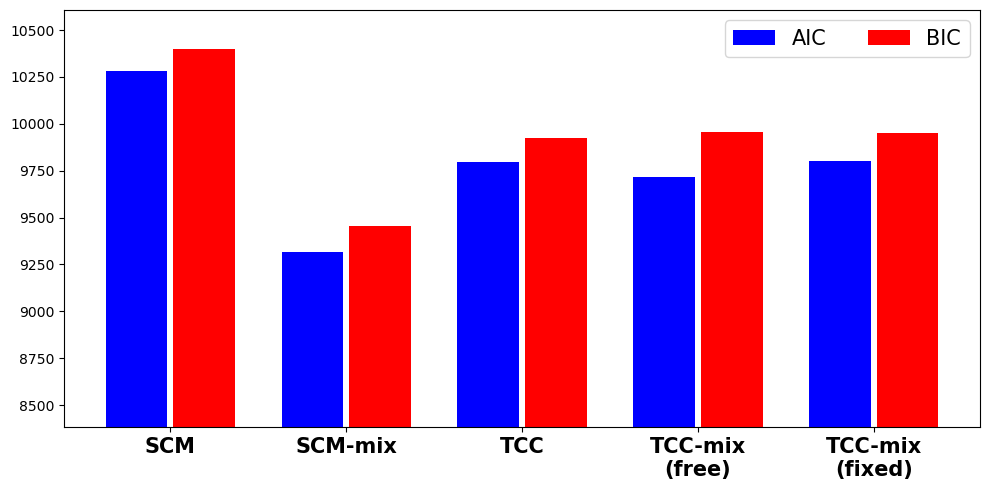

In [180]:
# AIC & BIC model comparison visualization

# AIC-BIC data
comparison_metrics_df = pd.DataFrame({'model':models.keys(),
                           'AIC': aic_values.values(),
                           'BIC': bic_values.values()})

fig, ax = plt.subplots(figsize = (10,5))

x = np.arange(len(comparison_metrics_df['model']))
width = 0.35

ax.bar(x - 0.55*width, comparison_metrics_df['AIC'], width,
       color='blue', label='AIC')

ax.bar(x + 0.55*width, comparison_metrics_df['BIC'], width,
       color='red', label='BIC')

ax.set_xticks(x)
model_names_plot = ['SCM', 'SCM-mix', 'TCC', 'TCC-mix\n(free)', 'TCC-mix\n(fixed)']
ax.set_xticklabels(model_names_plot,fontsize = 15, fontweight='bold')

miny = comparison_metrics_df[['AIC','BIC']].min().min()*.9
maxy = comparison_metrics_df[['AIC','BIC']].max().max()*1.02
ax.set_ylim([miny, maxy])

ax.legend(fontsize = 15, loc = 'upper right', ncol = 2)
plt.tight_layout()
plt.show()

## Correlations

In [181]:
def compute_correlations(predictions, SET_SIZES, POSITIONS):
    pred_probs = predictions['pred_probs']
    obs_props  = predictions['obs_props']
    n_pos      = predictions['n_pos']
    obs_mean   = obs_props.mean(axis=0)   # (12, 16, 16)

    print(f"{'Condition':<20} {'r':<10} {'p-value':<15}")
    print("-" * 45)

    results = []
    for i, ss in enumerate(SET_SIZES):
        for j, pos in enumerate(POSITIONS):
            cond_idx = i * n_pos + j
            pred = pred_probs[cond_idx].flatten()
            obs  = obs_mean[cond_idx].flatten()
            r, p = pearsonr(pred, obs)
            results.append({'set_size': ss, 'position': pos, 'r': r, 'p': p})
            print(f"SS={ss}, Pos={pos:<8} r={r:.3f}    p={p:.3f}")

    return pd.DataFrame(results)

In [182]:
# SCM correlations
corr_SCM = compute_correlations(SCM_predictions, SET_SIZES, POSITIONS)

Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.935    p=0.000
SS=2, Pos=7        r=0.965    p=0.000
SS=2, Pos=11       r=0.961    p=0.000
SS=2, Pos=15       r=0.948    p=0.000
SS=5, Pos=3        r=0.860    p=0.000
SS=5, Pos=7        r=0.883    p=0.000
SS=5, Pos=11       r=0.805    p=0.000
SS=5, Pos=15       r=0.816    p=0.000
SS=8, Pos=3        r=0.897    p=0.000
SS=8, Pos=7        r=0.900    p=0.000
SS=8, Pos=11       r=0.880    p=0.000
SS=8, Pos=15       r=0.871    p=0.000


In [183]:
# SCM-mix correlations
corr_SCM_mix = compute_correlations(SCM_mix_predictions, SET_SIZES, POSITIONS)

Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.967    p=0.000
SS=2, Pos=7        r=0.978    p=0.000
SS=2, Pos=11       r=0.985    p=0.000
SS=2, Pos=15       r=0.975    p=0.000
SS=5, Pos=3        r=0.942    p=0.000
SS=5, Pos=7        r=0.924    p=0.000
SS=5, Pos=11       r=0.929    p=0.000
SS=5, Pos=15       r=0.903    p=0.000
SS=8, Pos=3        r=0.945    p=0.000
SS=8, Pos=7        r=0.926    p=0.000
SS=8, Pos=11       r=0.926    p=0.000
SS=8, Pos=15       r=0.937    p=0.000


In [184]:
# TCC correlations
corr_TCC = compute_correlations(TCC_predictions, SET_SIZES, POSITIONS)

Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.951    p=0.000
SS=2, Pos=7        r=0.968    p=0.000
SS=2, Pos=11       r=0.981    p=0.000
SS=2, Pos=15       r=0.964    p=0.000
SS=5, Pos=3        r=0.933    p=0.000
SS=5, Pos=7        r=0.928    p=0.000
SS=5, Pos=11       r=0.930    p=0.000
SS=5, Pos=15       r=0.908    p=0.000
SS=8, Pos=3        r=0.929    p=0.000
SS=8, Pos=7        r=0.925    p=0.000
SS=8, Pos=11       r=0.919    p=0.000
SS=8, Pos=15       r=0.933    p=0.000


In [ ]:
# TCC-mix (free bias) correlations
corr_TCC_mix_free = compute_correlations(TCC_mix_free_predictions, SET_SIZES, POSITIONS)

Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.948    p=0.000
SS=2, Pos=7        r=0.963    p=0.000
SS=2, Pos=11       r=0.977    p=0.000
SS=2, Pos=15       r=0.961    p=0.000
SS=5, Pos=3        r=0.935    p=0.000
SS=5, Pos=7        r=0.933    p=0.000
SS=5, Pos=11       r=0.922    p=0.000
SS=5, Pos=15       r=0.907    p=0.000
SS=8, Pos=3        r=0.933    p=0.000
SS=8, Pos=7        r=0.931    p=0.000
SS=8, Pos=11       r=0.918    p=0.000
SS=8, Pos=15       r=0.934    p=0.000


In [186]:
# TCC-mix (fixed bias) correlations
corr_TCC_mix_fixed = compute_correlations(TCC_mix_fixed_predictions, SET_SIZES, POSITIONS)

Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.950    p=0.000
SS=2, Pos=7        r=0.967    p=0.000
SS=2, Pos=11       r=0.981    p=0.000
SS=2, Pos=15       r=0.963    p=0.000
SS=5, Pos=3        r=0.932    p=0.000
SS=5, Pos=7        r=0.929    p=0.000
SS=5, Pos=11       r=0.930    p=0.000
SS=5, Pos=15       r=0.908    p=0.000
SS=8, Pos=3        r=0.930    p=0.000
SS=8, Pos=7        r=0.925    p=0.000
SS=8, Pos=11       r=0.920    p=0.000
SS=8, Pos=15       r=0.934    p=0.000


## Visualization

In [187]:
# Match colors on the plot to those in the paper (the actual presented colors)
L, a_center, b_center, radius = 50, 10, 10, 40
angles = np.linspace(0, -360, 16, endpoint=False)
angles_rad = np.deg2rad(angles)

item_colors = []
for angle in angles_rad:
    a = a_center + radius * np.cos(angle)
    b = b_center + radius * np.sin(angle)
    lab = LabColor(L, a, b)
    rgb = convert_color(lab, sRGBColor)
    r  = np.clip(rgb.clamped_rgb_r, 0, 1)
    g  = np.clip(rgb.clamped_rgb_g, 0, 1)
    b_ = np.clip(rgb.clamped_rgb_b, 0, 1)
    item_colors.append((r, g, b_))

In [188]:
def plot_predicted_vs_observed(predictions, SET_SIZES, POSITIONS,
                                model_name='Model',
                                error_type='ci',
                                markersize=6,
                                legend_fontsize=10,
                                legend_title_fontsize=15,
                                legend_markersize=15):

    pred_probs = predictions['pred_probs']
    obs_props  = predictions['obs_props']
    n_subj     = predictions['n_subj']
    n_ss       = predictions['n_ss']
    n_pos      = predictions['n_pos']

    colors = item_colors

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=colors[row],
                                   markersize=legend_markersize,
                                   label=f'Item {row+1}')
                       for row in range(16)]

    fig = plt.figure(figsize=(14, 11))

    legend_ax = fig.add_axes([0, 0.88, 1, 0.06])
    legend_ax.axis('off')
    legend_ax.legend(handles=legend_elements, loc='center', ncol=8,
                     fontsize=legend_fontsize,
                     title='Studied item',
                     title_fontsize=legend_title_fontsize,
                     frameon=True,
                     labelspacing=0.85)

    fig.suptitle(f'{model_name}: Predicted vs Observed\n(all subjects)',
                 fontsize=20, fontweight='bold', y=1.01)

    gs = fig.add_gridspec(n_ss, n_pos, top=0.84, bottom=0.08,
                          left=0.08, right=0.98,
                          hspace=0.15, wspace=0.2)
    axes = gs.subplots(sharex=True, sharey=True)

    for i, ss in enumerate(SET_SIZES):
        for j, pos in enumerate(POSITIONS):
            ax = axes[i, j]
            cond_idx = i * n_pos + j

            for row in range(16):
                pred         = pred_probs[cond_idx, row, :]
                obs_per_subj = obs_props[:, cond_idx, row, :]
                obs_mean     = obs_per_subj.mean(axis=0)
                obs_std      = obs_per_subj.std(axis=0)

                if error_type == 'ci':
                    t_crit = stats.t.ppf(0.975, df=n_subj - 1)
                    err    = t_crit * obs_std / np.sqrt(n_subj)
                else:
                    err = obs_std / np.sqrt(n_subj)

                ax.errorbar(pred, obs_mean, yerr=err,
                            fmt='o', markersize=markersize, alpha=0.7,
                            elinewidth=0.8, capsize=2,
                            color=colors[row])

            lim = max(pred_probs[cond_idx].max(),
                      (obs_props[:, cond_idx].mean(axis=0) + err).max()) * 1.05
            ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
            ax.set_title(f'SS={ss}, Pos={pos}', fontsize=10)

    if error_type == 'ci':
        y_label = 'Observed Probability\n(mean ± 95% CI)'
    else:
        y_label = 'Observed Probability\n(mean ± SEM)'

    fig.text(0.5, 0.02, 'Predicted Probability', ha='center',
             fontsize=15, fontweight='bold')
    fig.text(0.01, 0.45, y_label, va='center', rotation='vertical',
             multialignment='center', fontsize=15, fontweight='bold')
    plt.show()

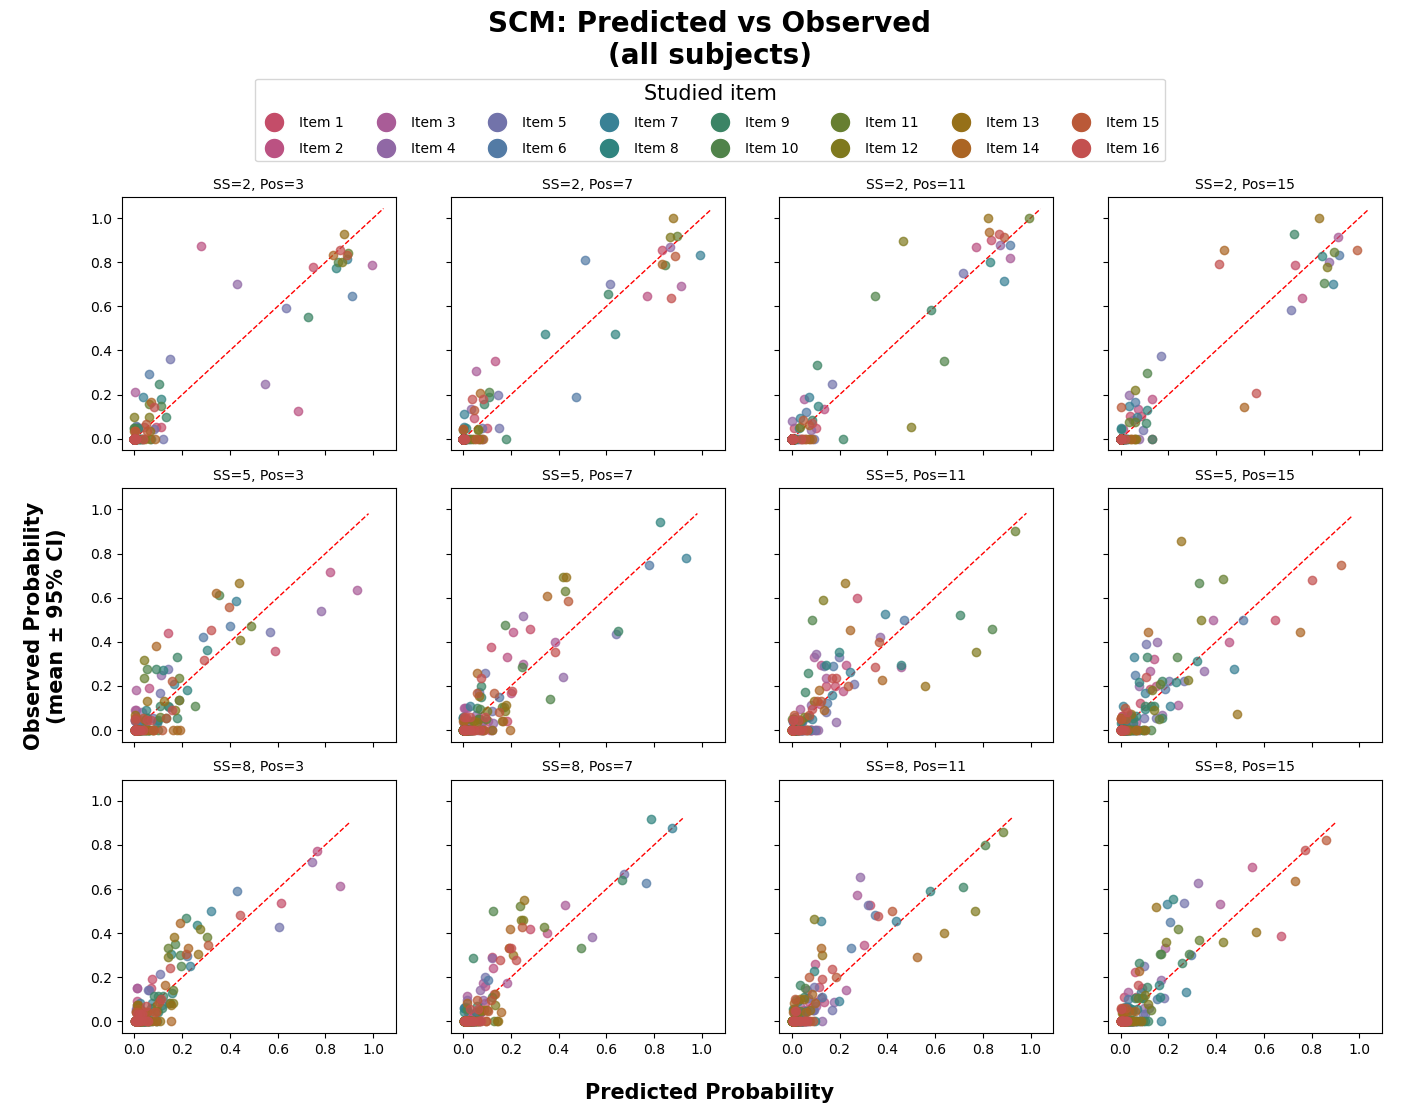

In [189]:
# SCM predictions
plot_predicted_vs_observed(SCM_predictions, SET_SIZES, POSITIONS, model_name='SCM')

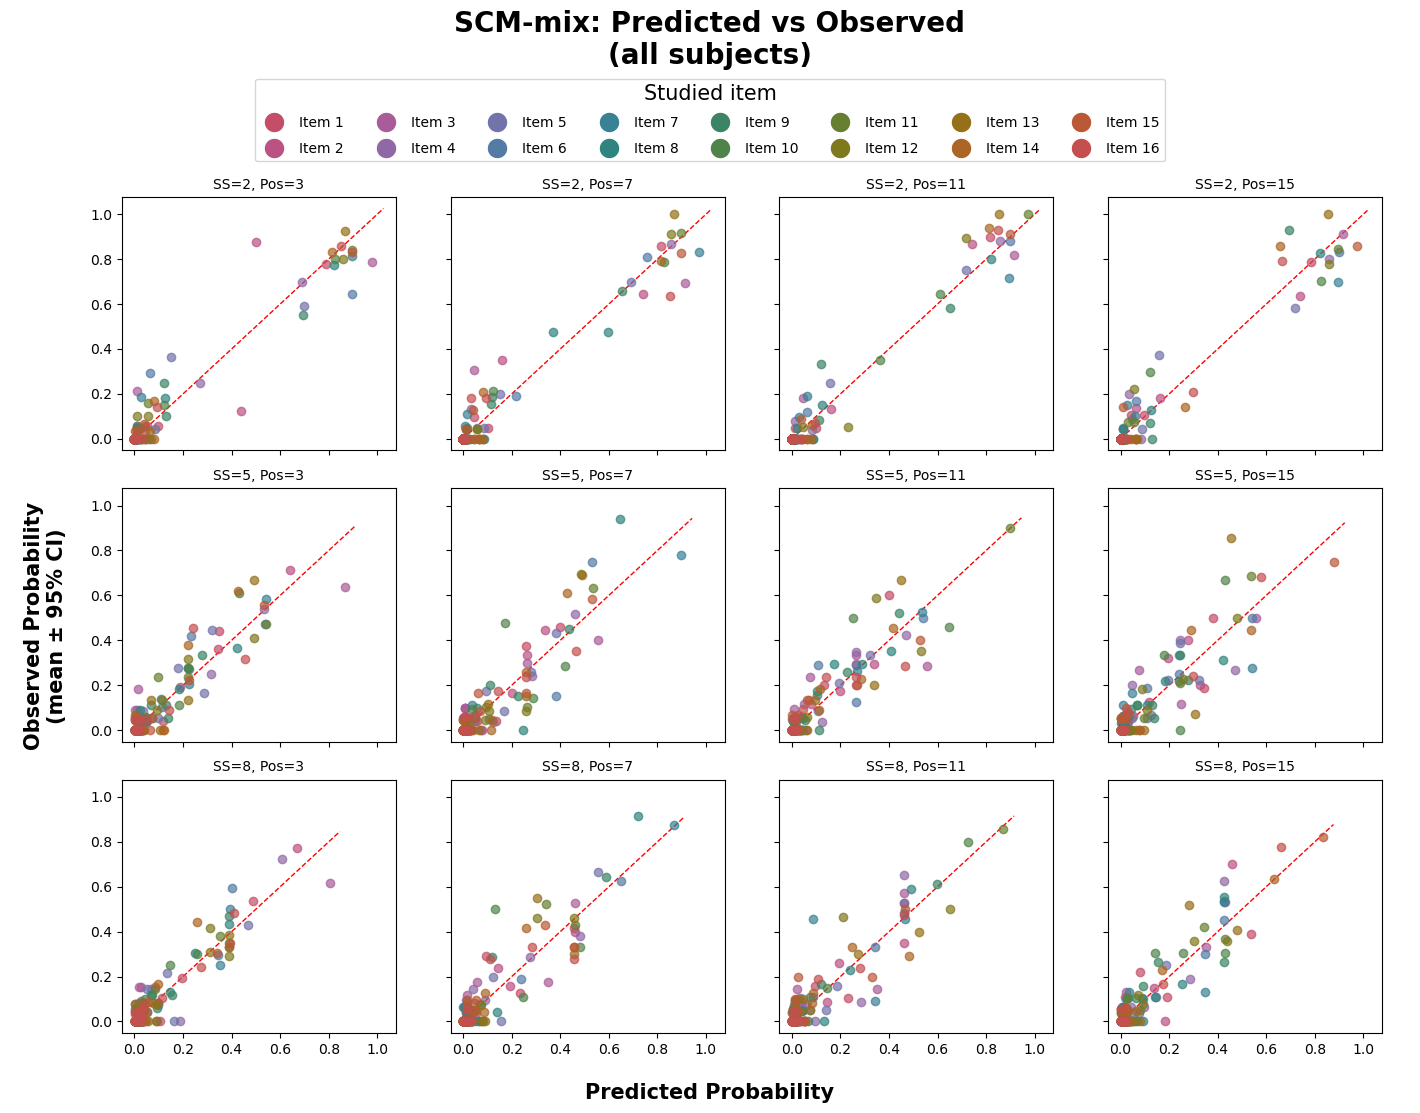

In [190]:
# SCM-mix predictions vs observed
plot_predicted_vs_observed(SCM_mix_predictions, SET_SIZES, POSITIONS, model_name='SCM-mix')

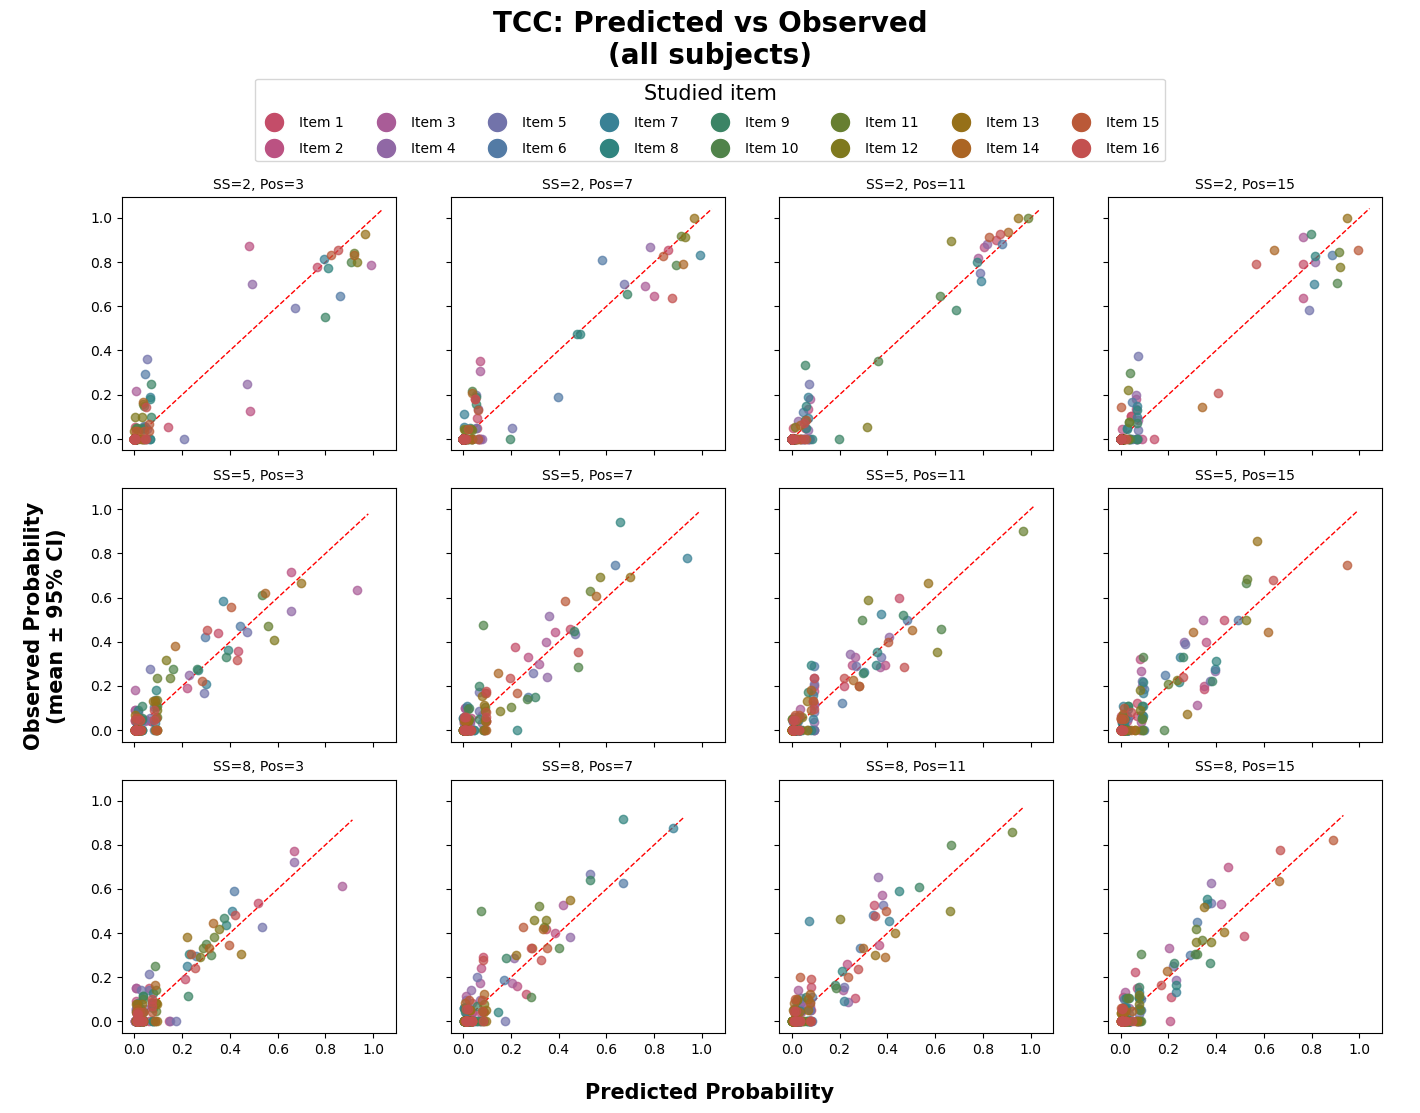

In [191]:
# TCC predictions vs observed
plot_predicted_vs_observed(TCC_predictions, SET_SIZES, POSITIONS, model_name='TCC')

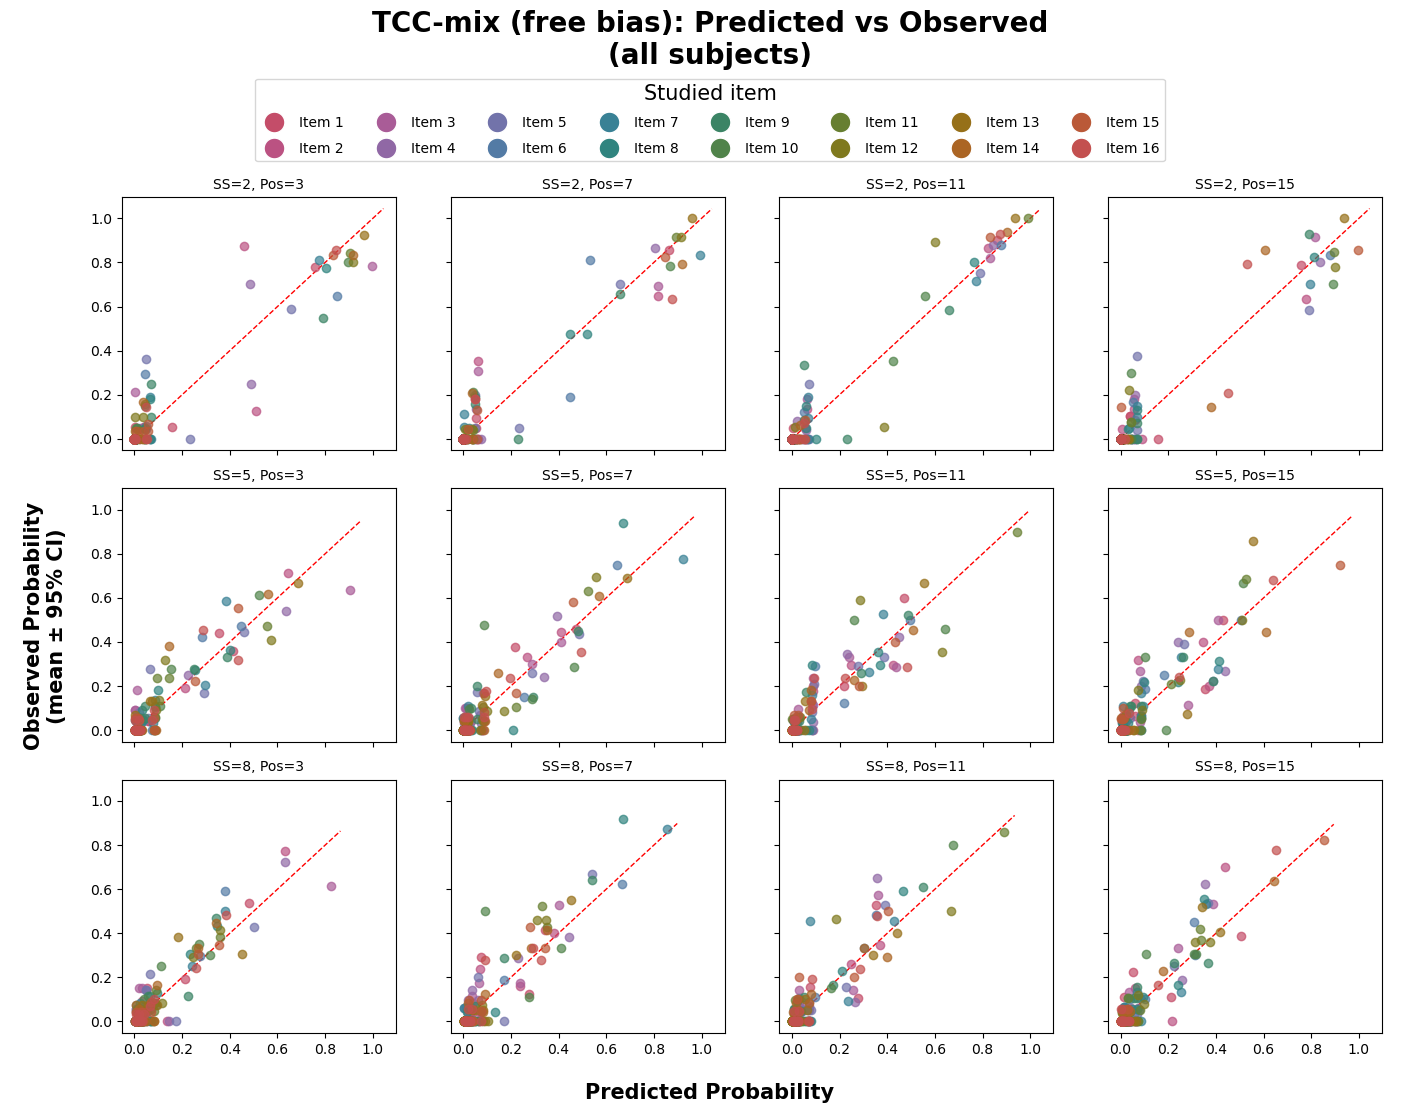

In [193]:
# TCC-mix (free bias) predictions vs observed
plot_predicted_vs_observed(TCC_mix_free_predictions, SET_SIZES, POSITIONS, model_name='TCC-mix (free bias)')

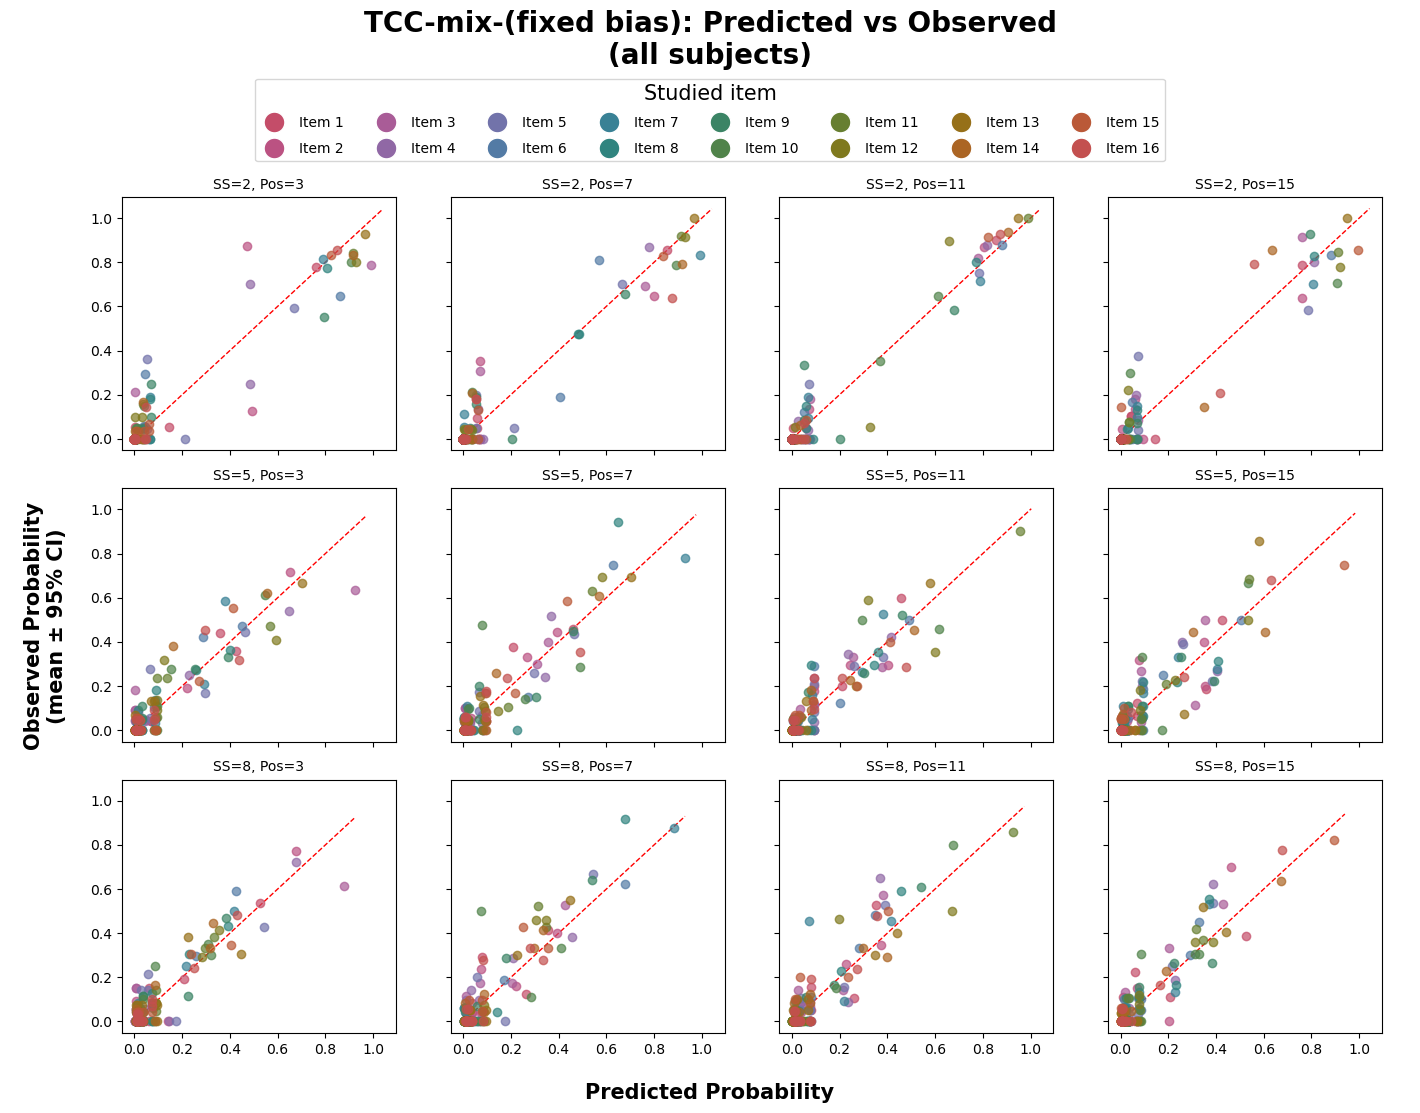

In [194]:
# TCC-mix (fixed) predictions vs observed
plot_predicted_vs_observed(TCC_mix_fixed_predictions, SET_SIZES, POSITIONS, model_name='TCC-mix-(fixed bias)')

## Aggregated accross conditions

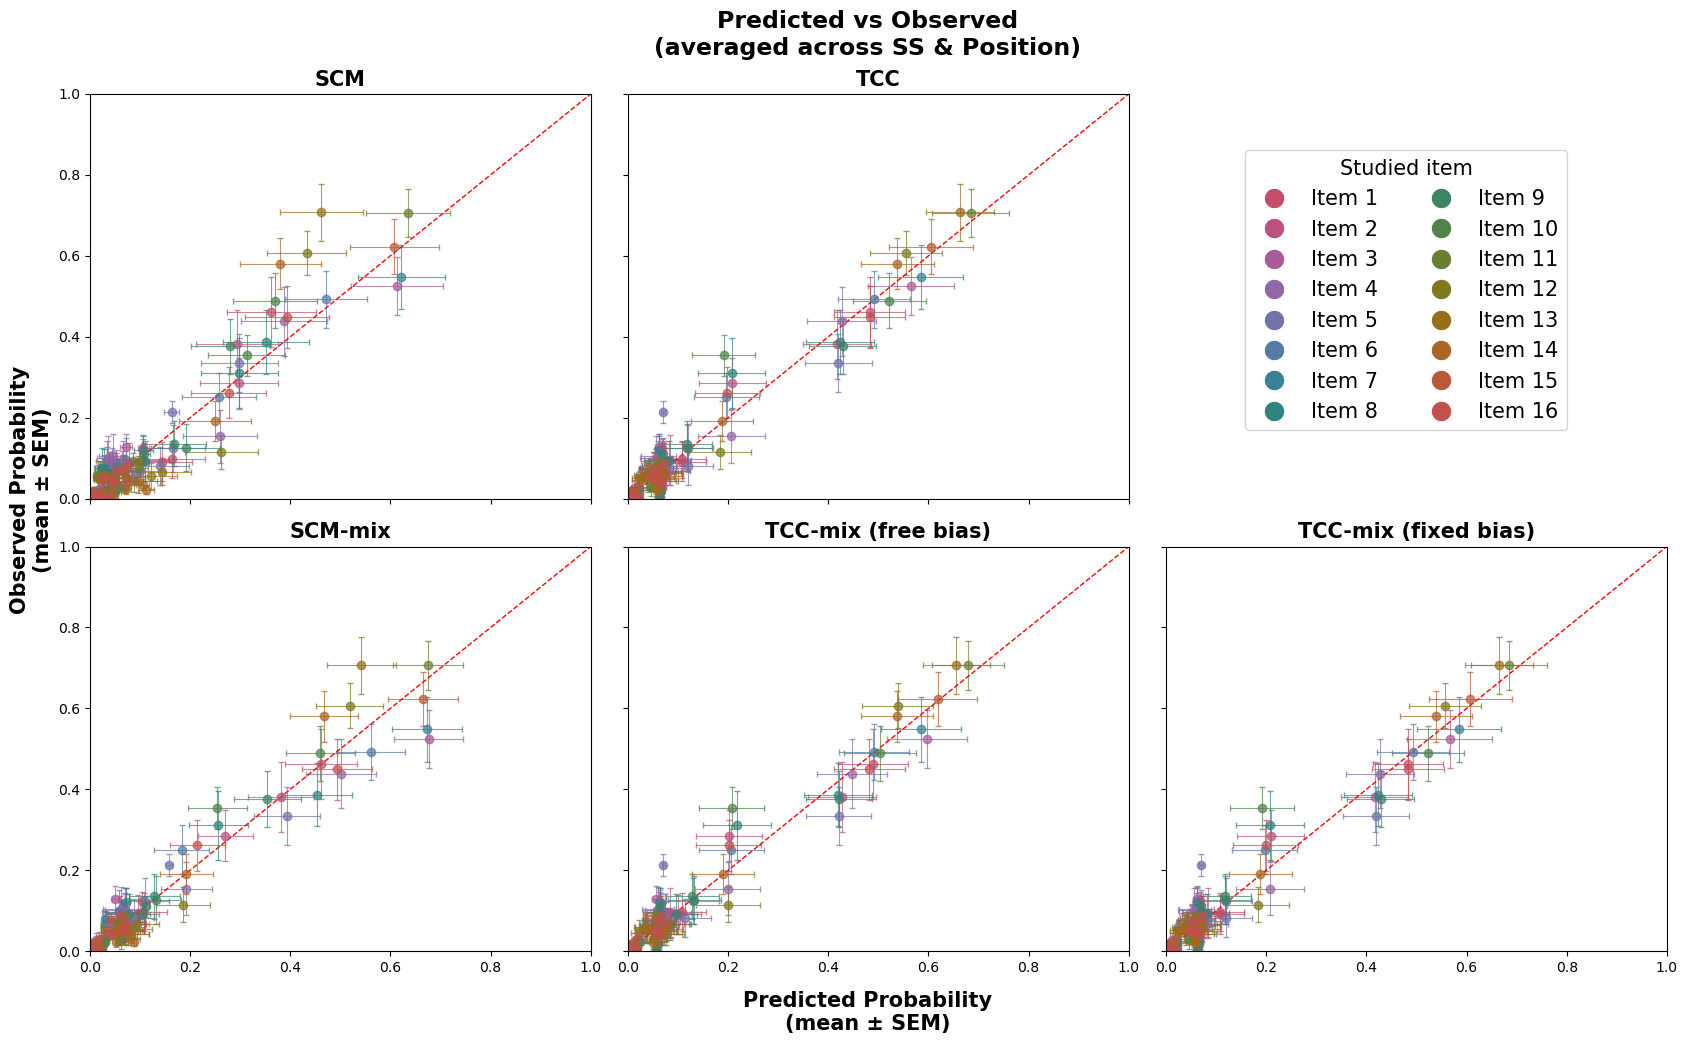

In [202]:
def plot_predicted_vs_observed_comparison(predictions_dict,
                                           error_type='sem',
                                           markersize=6,
                                           legend_fontsize=15,
                                           legend_title_fontsize=15,
                                           legend_markersize=15):
    colors = item_colors

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=colors[row],
                                   markersize=legend_markersize,
                                   label=f'Item {row+1}')
                       for row in range(16)]

    # Fixed layout: row 0 = simple models, row 1 = mixture models
    layout = [
        ['SCM',                 'TCC',                None              ],  # row 0: simple
        ['SCM-mix', 'TCC-mix (free bias)', 'TCC-mix (fixed bias)'],         # row 1: mixture
    ]
    nrows, ncols = 2, 3

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(16.5, 10),
                             sharex=True, sharey=True,
                             squeeze=False)

    for row_idx, row_layout in enumerate(layout):
        for col_idx, model_name in enumerate(row_layout):
            ax = axes[row_idx, col_idx]

            if model_name is None or model_name not in predictions_dict:
                ax.set_visible(False)
                continue

            predictions = predictions_dict[model_name]
            pred_probs  = predictions['pred_probs']
            obs_props   = predictions['obs_props']
            n_ss        = predictions['n_ss']
            n_pos       = predictions['n_pos']
            n_cond      = n_ss * n_pos

            for item in range(16):
                pred_item = pred_probs[:, item, :]
                obs_item  = obs_props[:, :, item, :].mean(axis=0)

                pred_mean = pred_item.mean(axis=0)
                pred_std  = pred_item.std(axis=0)
                obs_mean  = obs_item.mean(axis=0)
                obs_std   = obs_item.std(axis=0)

                if error_type == 'ci':
                    t_crit = stats.t.ppf(0.975, df=n_cond - 1)
                    xerr   = t_crit * pred_std / np.sqrt(n_cond)
                    yerr   = t_crit * obs_std  / np.sqrt(n_cond)
                else:
                    xerr = pred_std / np.sqrt(n_cond)
                    yerr = obs_std  / np.sqrt(n_cond)

                ax.errorbar(pred_mean, obs_mean,
                            yerr=yerr, xerr=xerr,
                            fmt='o', markersize=markersize, alpha=0.7,
                            elinewidth=0.8, capsize=2,
                            color=colors[item])

            ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
            ax.set_title(model_name, fontsize=legend_title_fontsize, fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

    if error_type == 'ci':
        y_label = 'Observed Probability\n(mean ± 95% CI)'
        x_label = 'Predicted Probability\n(mean ± 95% CI)'
    else:
        y_label = 'Observed Probability\n(mean ± SEM)'
        x_label = 'Predicted Probability\n(mean ± SEM)'

    fig.text(0.5,  -0.04, x_label, ha='center',
             fontsize=legend_title_fontsize, fontweight='bold',
             multialignment='center')
    fig.text(-0.02, 0.5,  y_label, va='center', rotation='vertical',
             fontsize=legend_title_fontsize, fontweight='bold',
             multialignment='center')

    # Legend in empty top-right cell (row 0, col 2)
    axes[0, 2].set_visible(False)
    fig.legend(handles=legend_elements,
               loc='upper right',
               bbox_to_anchor=(0.93, 0.85),
               ncol=2,
               fontsize=legend_fontsize,
               title='Studied item',
               title_fontsize=legend_title_fontsize,
               frameon=True)

    fig.suptitle('Predicted vs Observed\n(averaged across SS & Position)',
                 fontsize=legend_title_fontsize+2, fontweight='bold')

    plt.tight_layout()
    plt.show()


# ==================== Plot ====================
predictions_dict = {
    'SCM':         SCM_predictions,
    'SCM-mix':     SCM_mix_predictions,
    'TCC':      TCC_predictions,
    'TCC-mix (free bias)':      TCC_mix_free_predictions,
    'TCC-mix (fixed bias)':      TCC_mix_fixed_predictions,
}

plot_predicted_vs_observed_comparison(predictions_dict, error_type='sem')

## Subj 4

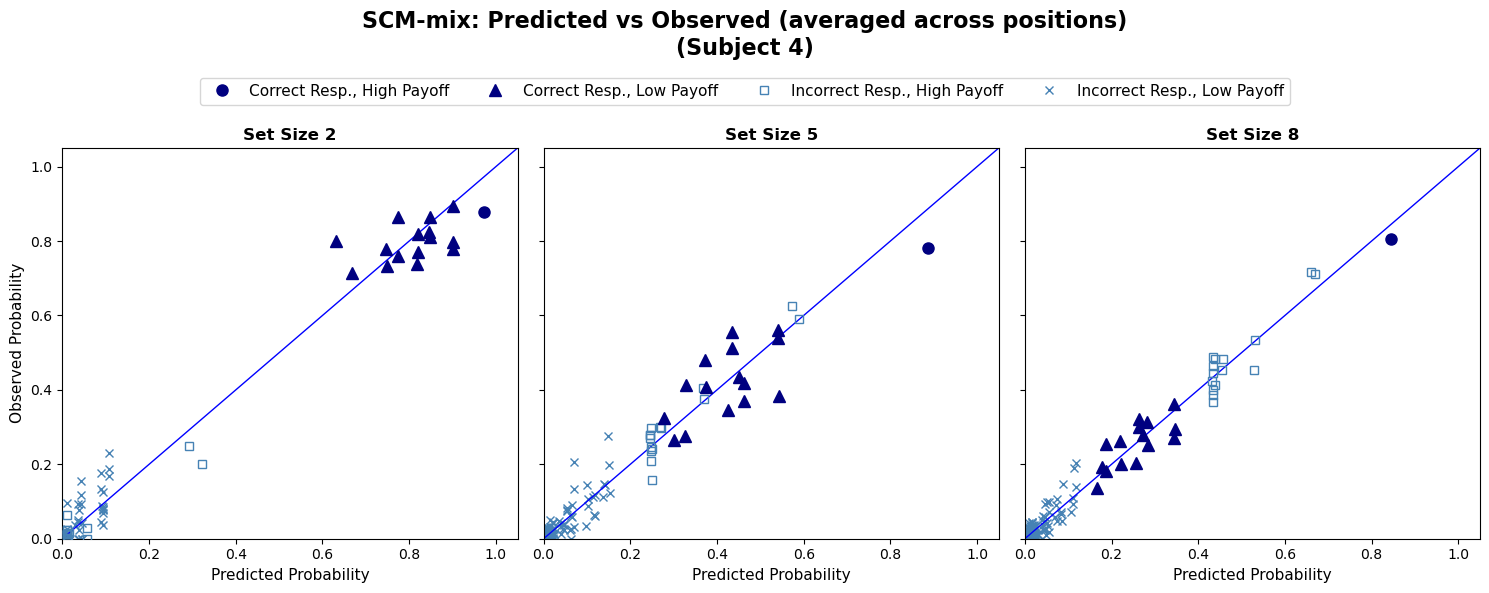

In [206]:
# Reproduce Figure 8 from the paper
def plot_pred_vs_obs_subject_avgpos(predictions, 
                                    SET_SIZES, POSITIONS, 
                                    subject_id=4,
                                    model_name='Model'):
    pred_probs = predictions['pred_probs']  # (12, 16, 16)
    n_pos      = predictions['n_pos']

    n_ss = len(SET_SIZES)
    fig, axes = plt.subplots(1, n_ss, figsize=(15, 6), sharey=True)
    fig.suptitle(f'{model_name}: Predicted vs Observed (averaged across positions)\n(Subject {subject_id})',
                 fontsize=16, fontweight='bold')

    styles = {
        'correct_high':   dict(marker='o', color='navy',      markersize=8,  label='Correct Resp., High Payoff',   linestyle='None', zorder=5),
        'correct_low':    dict(marker='^', color='navy',      markersize=8,  label='Correct Resp., Low Payoff',    linestyle='None', zorder=4),
        'incorrect_high': dict(marker='s', color='steelblue', markersize=6,  label='Incorrect Resp., High Payoff', linestyle='None', markerfacecolor='none', zorder=3),
        'incorrect_low':  dict(marker='x', color='steelblue', markersize=6,  label='Incorrect Resp., Low Payoff',  linestyle='None', zorder=2),
    }

    for i, ss in enumerate(SET_SIZES):
        ax = axes[i]

        # --- observed: use aggregated data directly ---
        obs_counts = data[subject_id]['aggregated'][ss]           # (16, 16) already relabeled
        obs_avg    = obs_counts / obs_counts.sum(axis=1, keepdims=True)  # normalize rows

        # --- predicted: relabel and average across 4 positions ---
        pred_relabeled = np.zeros((n_pos, 16, 16))
        for j, pos in enumerate(POSITIONS):
            cond_idx = i * n_pos + j
            p = pos - 1
            pred_mat = pred_probs[cond_idx]
            pred_relabeled[j] = np.roll(np.roll(pred_mat, -p, axis=0), -p, axis=1)
        pred_avg = pred_relabeled.mean(axis=0)                    # (16, 16)

        # --- categorize ---
        cat_pred = {k: [] for k in styles}
        cat_obs  = {k: [] for k in styles}

        for row in range(16):
            for col in range(16):
                correct = (row == col)
                high    = (col == 0)  # col 0 = high-payoff after relabeling

                if correct and high:
                    cat = 'correct_high'
                elif correct and not high:
                    cat = 'correct_low'
                elif not correct and high:
                    cat = 'incorrect_high'
                else:
                    cat = 'incorrect_low'

                cat_pred[cat].append(pred_avg[row, col])
                cat_obs[cat].append(obs_avg[row, col])

        for cat, style in styles.items():
            if cat_pred[cat]:
                ax.plot(cat_pred[cat], cat_obs[cat], **style)

        lim = 1.05
        ax.plot([0, lim], [0, lim], 'b-', linewidth=1)
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_title(f'Set Size {ss}', fontsize=12, fontweight = 'bold')
        ax.set_xlabel('Predicted Probability', fontsize=11)
        if i == 0:
            ax.set_ylabel('Observed Probability', fontsize=11)

    handles = [plt.Line2D([0], [0], **{k: v for k, v in s.items() if k != 'zorder'})
               for s in styles.values()]
    labels  = [s['label'] for s in styles.values()]
    fig.legend(handles, labels, fontsize=11, loc='upper center',
               bbox_to_anchor=(0.5, 0.88), ncol=4, frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.75)
    plt.show()

# Plot
plot_pred_vs_obs_subject_avgpos(SCM_mix_predictions, SET_SIZES, POSITIONS,
                                subject_id=4,
                                model_name='SCM-mix')

## Slides

In [207]:
def to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

def to_rgb255(r, g, b):
    return (int(r*255), int(g*255), int(b*255))

for i, (r, g, b) in enumerate(item_colors):
    print(f"Color {i}: hex={to_hex(r,g,b)}, rgb={to_rgb255(r,g,b)}")

Color 0: hex=#c34d68, rgb=(195, 77, 104)
Color 1: hex=#ba5181, rgb=(186, 81, 129)
Color 2: hex=#a95b97, rgb=(169, 91, 151)
Color 3: hex=#9067a5, rgb=(144, 103, 165)
Color 4: hex=#7272aa, rgb=(114, 114, 170)
Color 5: hex=#537ba4, rgb=(83, 123, 164)
Color 6: hex=#398095, rgb=(57, 128, 149)
Color 7: hex=#30837e, rgb=(48, 131, 126)
Color 8: hex=#3b8464, rgb=(59, 132, 100)
Color 9: hex=#4f8249, rgb=(79, 130, 73)
Color 10: hex=#677e30, rgb=(103, 126, 48)
Color 11: hex=#7f781e, rgb=(127, 120, 30)
Color 12: hex=#966f18, rgb=(150, 111, 24)
Color 13: hex=#aa6423, rgb=(170, 100, 35)
Color 14: hex=#ba5937, rgb=(186, 89, 55)
Color 15: hex=#c3504f, rgb=(195, 80, 79)


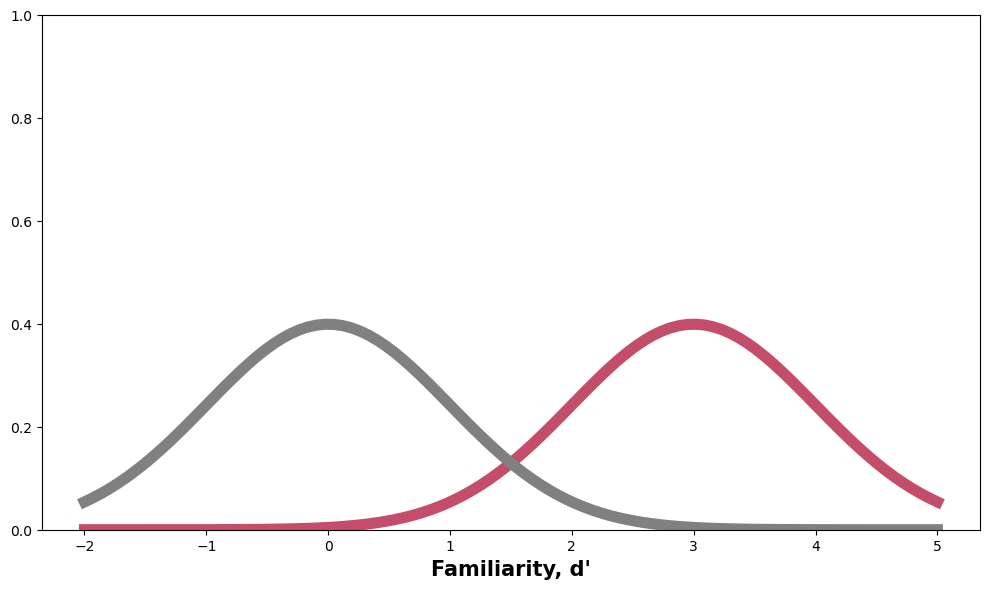

In [208]:
Xs = np.linspace(-2,5,100)
item1_d = 3
pdfs = stats.norm.pdf(Xs, loc=item1_d, scale=1)
pdf_noise = stats.norm.pdf(Xs, loc=0, scale=1)

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(Xs, pdfs, color=item_colors[0],linewidth=8)
ax.plot(Xs, pdf_noise, color='grey',linewidth=8)

ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
ax.set_ylim((0,1))
plt.tight_layout()
plt.show()

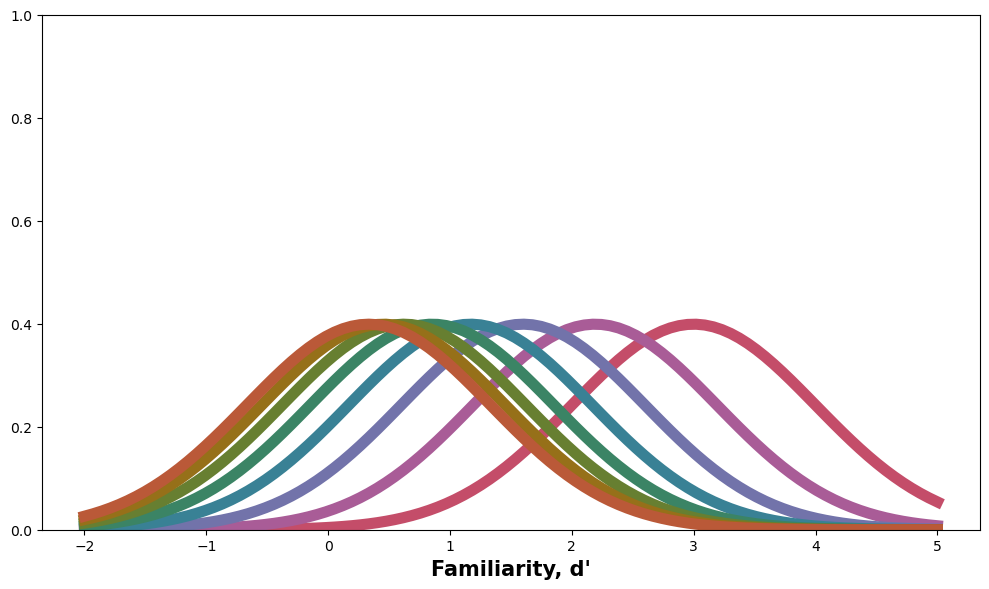

In [209]:
n_obj = 8
Xs = np.linspace(-2,5,100)
dist = np.linspace(0, 2, n_obj)
item1_d = 3
c = 1.1
sim = np.exp(-c * dist)
all_d = item1_d * sim

fig, ax = plt.subplots(figsize=(10,6))
pdfs = stats.norm.pdf(Xs[None,:], loc=all_d[:,None], scale=1)
for i in range(pdfs.shape[0]):
    plt.plot(Xs, pdfs[i], color = item_colors[int(i*(16/n_obj))], linewidth=8)

ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
ax.set_ylim((0,1))
plt.tight_layout()
plt.show()

In [210]:
# Visualization of how integral is calculated for d'
def integral_vis(n_obj = 8,
                 Xs = np.linspace(-2,5,100),
                 item1_d = 3,
                 c = 1.1,
                 pdf_idx = 0,
                 x_integral = 3.5):

    dist = np.linspace(0, 2, n_obj)
    sim = np.exp(-c * dist)
    all_d = item1_d * sim

    fig, ax = plt.subplots(figsize=(10,6))
    pdfs = stats.norm.pdf(Xs, loc=all_d[pdf_idx], scale=1) # target
    cdfs = stats.norm.cdf(Xs[None, :], loc = all_d[:, None], scale = 1)

    for i in range(n_obj):
        color_idx = int( i*(16/n_obj) )
        if i == pdf_idx:
            plt.plot(Xs, pdfs, color = item_colors[color_idx], linewidth=8)
        else:
            plt.plot(Xs, cdfs[i], color = item_colors[color_idx], linewidth=8)

    plt.axvline(x=x_integral, linestyle='--', linewidth=2, color='black')

    xticks = list(ax.get_xticks()) + [x_integral]
    ax.set_xticks(xticks)

    labels = []
    fw = []
    for t in xticks:
        if np.isclose(t, x_integral):
            labels.append('x')
            fw.append('bold')
        else:
            labels.append(f"{t:g}")
            fw.append('normal')

    ax.set_xticklabels(labels)

    for label, t in zip(ax.get_xticklabels(), xticks):
        if np.isclose(t, x_integral):
            label.set_fontweight('bold')
            label.set_fontsize(25)   # bigger for the special tick

    ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
    ax.set_ylim((0,1))
    plt.tight_layout()
    plt.show()

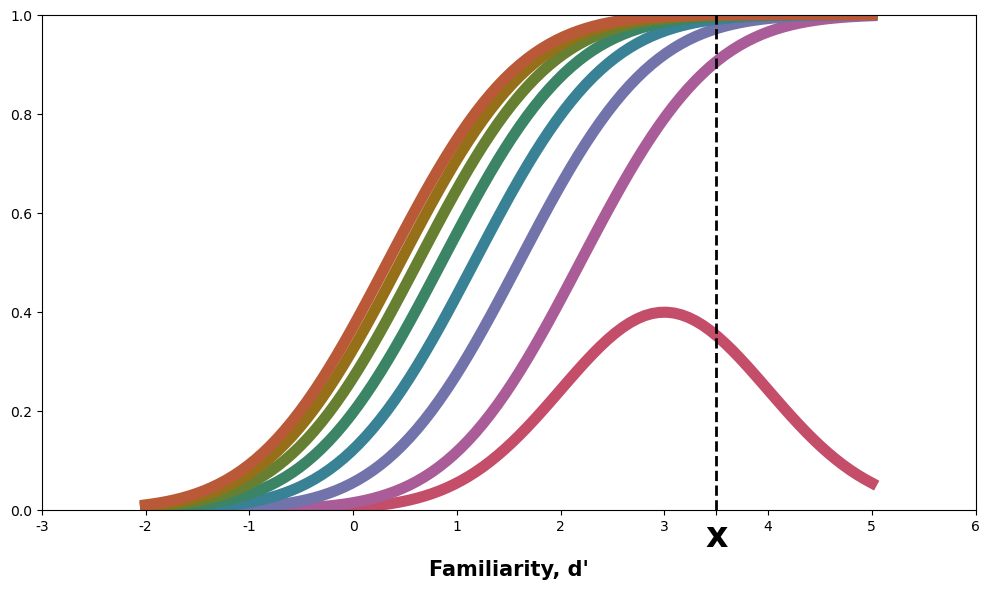

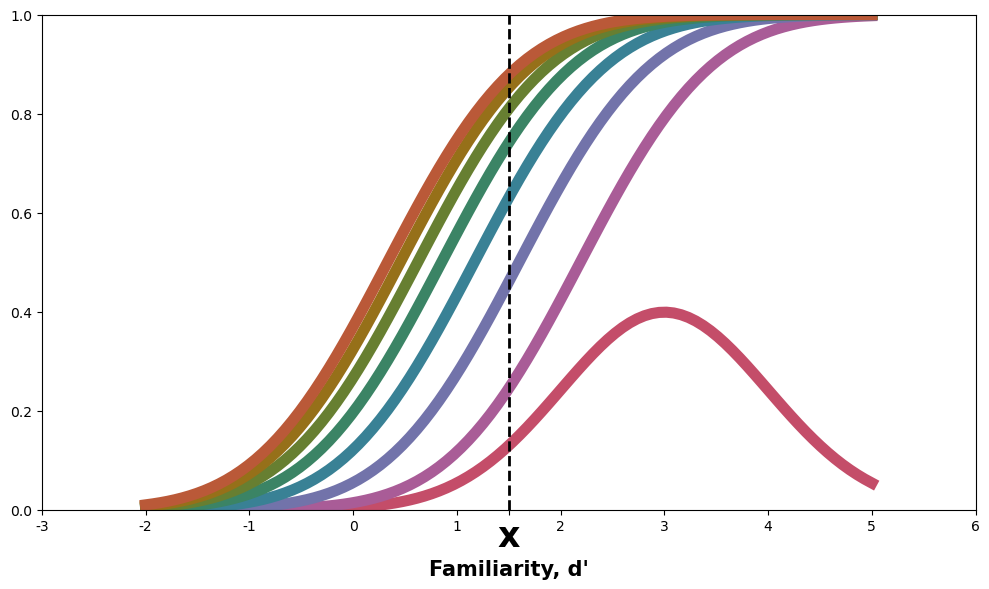

In [211]:
# Target
integral_vis(pdf_idx = 0, x_integral = 3.5)
integral_vis(pdf_idx = 0, x_integral = 1.5)

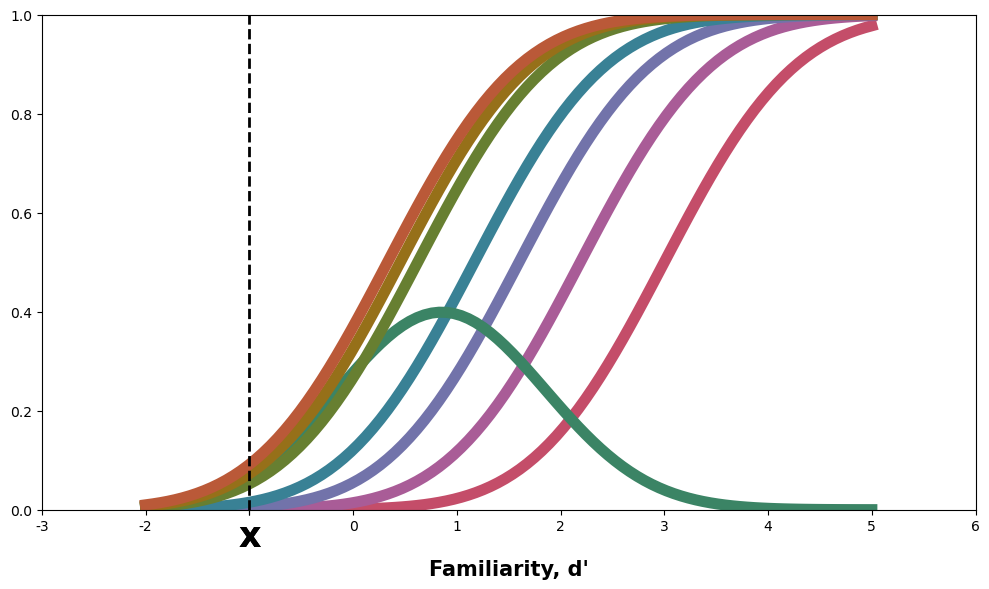

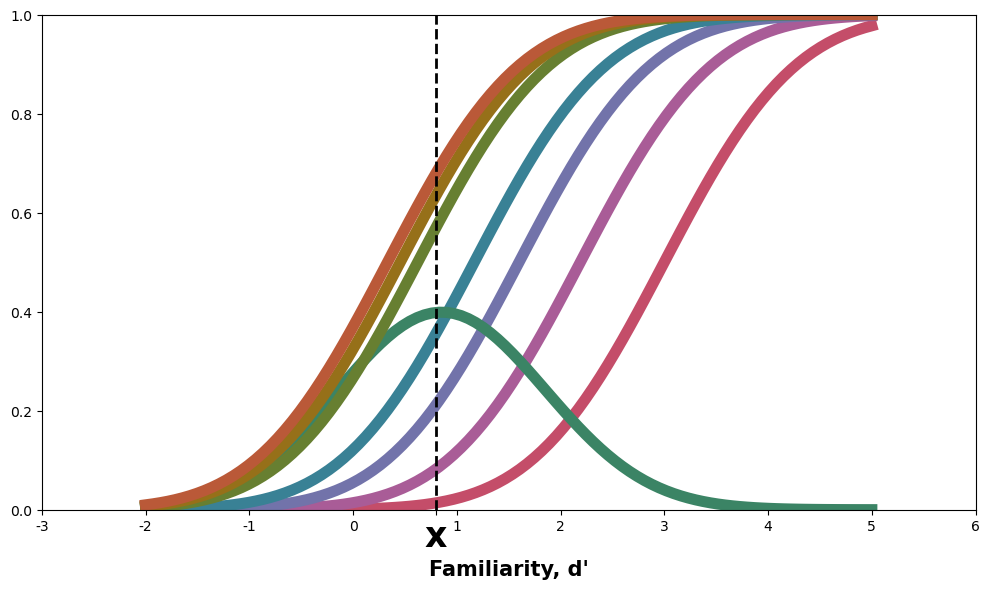

In [212]:
# Foil
integral_vis(pdf_idx = 4, x_integral = -1.0)
integral_vis(pdf_idx = 4, x_integral = 0.8)

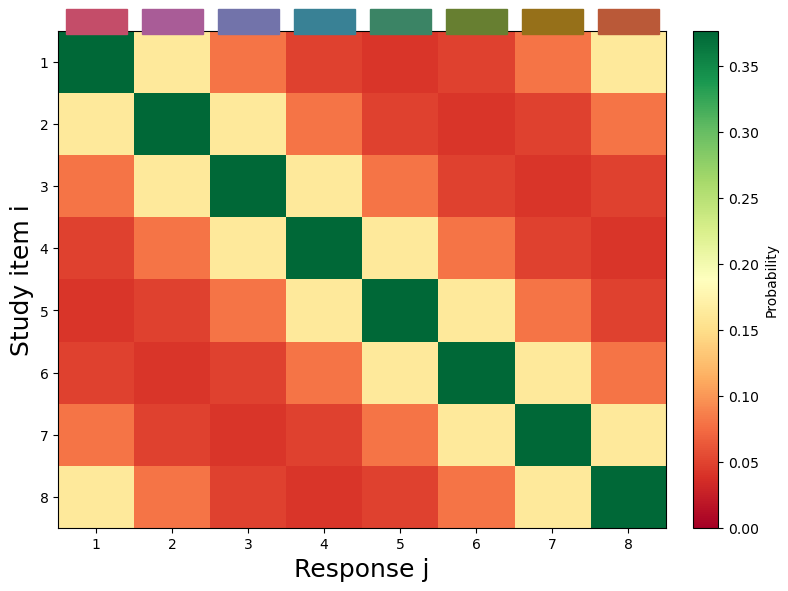

In [213]:
# 8 items on a circle
n = 8
item_angles = np.linspace(0, 2*np.pi, n, endpoint=False)
coords = np.stack([np.cos(item_angles), np.sin(item_angles)], axis=1)
dists = np.sqrt(((coords[:, None] - coords[None, :])**2).sum(axis=-1))

# Similarity and probabilities
c_val = 1.1
sim_mat = np.exp(-c_val * dists)
prob_mat = sim_mat / sim_mat.sum(axis=1, keepdims=True)  # (8, 8)

# Take just row 0 (first stimulus)
row = prob_mat[0:n,:]  # (1, 8)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

im = ax.imshow(row, cmap='RdYlGn', aspect='auto', vmin=0, vmax=row.max())

#ax.set_yticks([0])
#ax.set_yticklabels(['Stimulus 1'])
ax.set_yticks(range(n))
ax.set_yticklabels([f'{i+1}' for i in range(n)])
ax.set_ylabel('Study item i', fontsize=18)
ax.set_xticks(range(n))
ax.set_xticklabels([f'{i+1}' for i in range(n)])
ax.set_xlabel('Response j', fontsize=18)

# Color squares above each column
colors_subset = [item_colors[i*2] for i in range(n)]
for i, col in enumerate(colors_subset):
    ax.add_patch(plt.Rectangle((i-0.4, -0.85), 0.8, 0.4, color=col,
                                transform=ax.transData, clip_on=False, zorder=5))

plt.colorbar(im, ax=ax, fraction=0.06, pad=0.04, label='Probability')
plt.tight_layout()
plt.show()

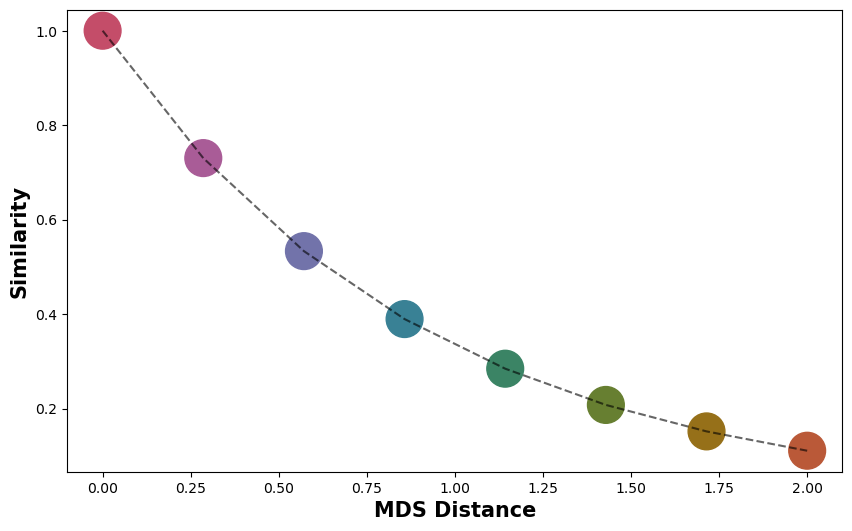

In [214]:
x = np.linspace(0, 2, 8)
c = 1.1
sim = np.exp(-c * x)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, sim, color="black", linestyle="--", alpha = 0.6)

# take every other point (0th, 2nd, 4th, ...)
idx = np.arange(0, len(item_colors), 2)

# match colors to those indices
selected_colors = [item_colors[i] for i in idx]

ax.scatter(x, sim, color=selected_colors, s=700)

ax.set_xlabel("MDS Distance", fontsize=15, fontweight="bold")
ax.set_ylabel("Similarity", fontsize=15, fontweight="bold")

plt.show()